# cNMF Program–Trait Enrichment Analysis
**Denis Torre, Huangfu Lab, MSKCC - 2026/05/14**

This notebook links transcription factor (TF) perturbation effects to GWAS traits through cNMF gene programs, building tripartite networks of TFs → Programs → Traits.

**Inputs:**
- `60_trait_enrichment.txt` – Enrichment p-values linking cNMF programs to GWAS trait terms (EFO IDs).
- `OpenTargets_L2G_Filtered.csv.gz` – Lookup table mapping EFO trait IDs to human-readable trait names.
- `60_perturbation_association_results_all.txt` – TF perturbation–program association results (log2FC, adjusted p-values).

The trait–program links and TF–program links were generated by the cNMF pipeline and downloaded from Synapse on hackathon day (2025/05/14).

**Analysis steps:**
1. Identifies significant TF–program associations (adj. p < 0.01, |log2FC| > 0.5) and significant program–trait links (P < 0.05).
2. Builds and visualizes a tripartite network graph for the top 5 GWAS traits by minimum p-value.
3. Filters traits to those relevant to endoderm-derived tissues (liver, pancreas, gut, lung, metabolic, etc.) and ranks them by the number of associated programs.
4. Generates individual network plots for the top 10 endoderm-relevant traits, and a detailed labeled network for Type 2 Diabetes.

**Outputs:**
- Bar chart of endoderm-relevant traits ranked by program connectivity.
- Network visualizations (TF–Program–Trait graphs) for the top 5 overall traits, top 10 endoderm traits, and a T2D-focused network.

In [1]:
library(data.table)
library(dplyr)
library(tibble)
library(ggplot2)
library(igraph)
library(ggraph)
library(tidygraph)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘igraph’


The following object is masked from ‘package:tibble’:

    as_data_frame


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Attaching package: ‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter




### 1. Read data

In [2]:
# Read data
trait_dataframe <- fread('/data1/huangfud/torred1/sandbox/sandbox009-tf_perturbseq_gwas/cnmf/60_trait_enrichment.txt') %>%
    rename_all(make.names) %>% 
    arrange(P.value)
head(trait_dataframe)

# Read
trait_name_dataframe <- fread('/data1/huangfud/torred1/sandbox/sandbox009-tf_perturbseq_gwas/cnmf/OpenTargets_L2G_Filtered.csv.gz') %>%
    select(trait_efos, trait_reported) %>% 
    distinct
head(trait_name_dataframe)

# Read perturbation-program association data
perturb_df <- fread('/data1/huangfud/torred1/sandbox/sandbox009-tf_perturbseq_gwas/cnmf/60_perturbation_association_results_all.txt') %>%
    rename_all(make.names) %>%
    mutate(program_label = paste0("P", program_name))


program_name,Term,P.value,Adjusted.P.value,Odds.Ratio,Combined.Score,Genes,overlap_numerator,overlap_denominator
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>
29,EFO_0006527,7.050489e-16,2.799044e-13,5.428631,189.39550,DLGAP1;HOOK1;ROBO2;CADM2;NRXN3;ZNF521;AUTS2;ST6GALNAC3;VTI1A;PCDH7;SOX5;NPAS3;FHIT;HS6ST3;LRRTM4;NLGN1;IMMP2L;CCDC171;RABGAP1L;TTC28;CNTN4;DPP10;HCN1;GPM6A;FOXN3;ADGRB3;TOX;RANBP17;SYT14;FOXP2;DIAPH3;EFNA5;TIAM1;AKT3;FAT3;MMS22L;ERC2;PRICKLE2;ADGRL3;BNC2;MED12L;DPYD;SDK1;ZNF423;THSD7B,45,214
45,EFO_0004784,6.879788e-14,2.683117e-11,4.218259,127.84533,PLCL2;FZD7;CAMK1D;ZNF385D;UTRN;DLG2;ATP11B;CADM1;TCF4;RORA;TENM2;GULP1;ROBO1;PRTG;ZNF521;ERBB4;RIMS2;AUTS2;LSAMP;ACVR2A;GLIS3;TENM4;PCDH7;NRG1;SOX5;FHIT;RUNX1T1;LDB2;TESC;SRGAP3;CALN1;TLE4;SSBP2;EPHA7;NEO1;PRKN;EYS;FAT3;PRKD1;LRRC7;DAB1;CNTNAP5;DSCAM;FST;NFIA;SATB2;PDE4D;SYT1;LARGE1;ETV1;KCNJ3,51,315
45,EFO_0004875,5.343148e-12,1.041914e-09,3.730264,96.81977,PLCL2;CAMK1D;SATB2;ZNF385D;UTRN;DLG2;TCF4;RORA;GULP1;ROBO1;ZNF521;ERBB4;AUTS2;LSAMP;ACVR2A;GLIS3;TENM4;PCDH7;FGF12;MEIS2;GABRB3;RUNX1T1;THSD7B;CNTN4;SRGAP3;PLCB1;CALN1;ZFPM2;TLE4;OSBPL3;GRM3;KIRREL3;GLI3;PLXDC2;PRKN;EYS;FAT3;PTCH1;LRRC7;CNTNAP5;KCNJ3;NALF1;NFIA;PREX1;PDE4D;NRXN1;LARGE1;ETV1;CNTNAP2;SYT1,50,339
29,EFO_0004784,2.657283e-11,3.702869e-09,3.628708,88.36314,KCNT2;NXPH2;CAMK1D;ROBO2;CADM2;ARID1B;RORA;ZNF521;AUTS2;RIMS2;MAGI1;LSAMP;TENM4;SDK1;PCDH7;SOX5;MACROD2;NPAS3;FHIT;RABGAP1L;PTK2;LDB2;ITPR2;FUT9;DENND1A;WWOX;GPM6A;FOXN3;CALN1;ADGRB3;SSBP2;FOXP2;EFNA5;DIAPH3;NEO1;DCLK1;CTNND2;FAT3;CUX1;DAB1;MAST4;PRICKLE2;NFIA;ADGRL3;DPYD;SYT1;LARGE1;ZNF423,48,315
29,"EFO_0003888, EFO_0007052, MONDO_0002491",3.290511e-11,3.702869e-09,4.608250,111.23113,HOOK1;ADGRL2;ROBO2;CADM2;ARID1B;CDK14;NRXN3;AUTS2;VTI1A;PCDH7;SOX5;MGAT5;HS6ST3;PRKG1;NLGN1;IMMP2L;RABGAP1L;TTC28;HCN1;ELMO1;BNC2;TOX;RANBP17;FOXP2;SYT14;EFNA5;AKT3;DAB1;ERC2;NFIA;ADGRL3;LRRTM4;SDK1;ZNF423;THSD7B,35,183
29,EFO_0004464,3.730851e-11,3.702869e-09,3.294091,79.09706,SEMA5A;ROBO2;ADGRV1;ARID1B;RORA;CDKAL1;DNAH11;KAZN;LRBA;RAD51B;AUTS2;MAGI1;PCSK5;MLLT3;ROR1;PCDH7;SOX5;MACROD2;MAPRE2;TTC28;FBXL7;CCDC171;PLEKHA7;GRIP1;WWOX;DENND1A;PDE8A;ELMO1;MTCL1;PDZD2;ANK3;TNIK;AGAP1;NRCAM;LTBP1;FOXP2;EXOC6B;DIAPH3;NEO1;EFNA5;DCLK1;GLI3;AKT3;PLXDC2;TMEM108;FAT3;THSD4;UNC5D;DAB1;MAST4;IRS1;NFIA;DPYD;BNC2;ZNF423,55,398


trait_efos,trait_reported
<chr>,<chr>
GO_0036273,Statin medication
GO_0044691,Primary tooth development (time to first tooth eruption)
GO_0042476,Primary tooth development (number of teeth)
EFO_0004354,Chronotype
EFO_0009105,High altitude adaptation
EFO_0004337,General cognitive ability


Significant edges: 361 
Unique TFs: 288 
Unique programs: 34 


target_name,program_name,ref_mean,test_mean,log2FC,stat,pval,adj_pval,program_label
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
SETDB1,49,0.004034689,0.021229721,2.3955559,41427808,0.000000e+00,0.000000e+00,P49
SOX17,45,0.004765074,0.072972421,3.9367806,26648022,0.000000e+00,0.000000e+00,P45
SOX17,52,0.003762247,0.023461938,2.6406555,24644029,1.017608e-243,4.196617e-239,P52
ZNF90,49,0.004034689,0.013255641,1.7160770,24886475,7.625816e-216,2.358665e-211,P49
FOXH1,52,0.003762247,0.035810444,3.2507136,20749876,9.412198e-203,2.328954e-198,P52
SOX17,46,0.006847024,0.037902809,2.4687557,23355468,1.831981e-179,3.777544e-175,P46
FOXH1,33,0.011102105,0.073371477,2.7243859,20138364,2.603955e-164,4.602305e-160,P33
SETDB1,34,0.011061398,0.018683135,0.7562028,34950427,5.119350e-98,7.037400e-94,P34
FOXH1,12,0.023464850,0.012511084,-0.9072943,7702230,4.812362e-88,5.953854e-84,P12


Top 5 traits:
EFO_0006527 -> Smoking initiation (ever regular vs never regular) (MTAG)
EFO_0004784 -> Educational attainment (years of education)
EFO_0004875 -> Highest math class taken (MTAG) [MTAG]
EFO_0003888, EFO_0007052, MONDO_0002491 -> Attention deficit hyperactivity disorder (MTAG)
EFO_0004464 -> Vertex-wise sulcal depth


Trait-Program edges: 112
TF-Program edges: 232

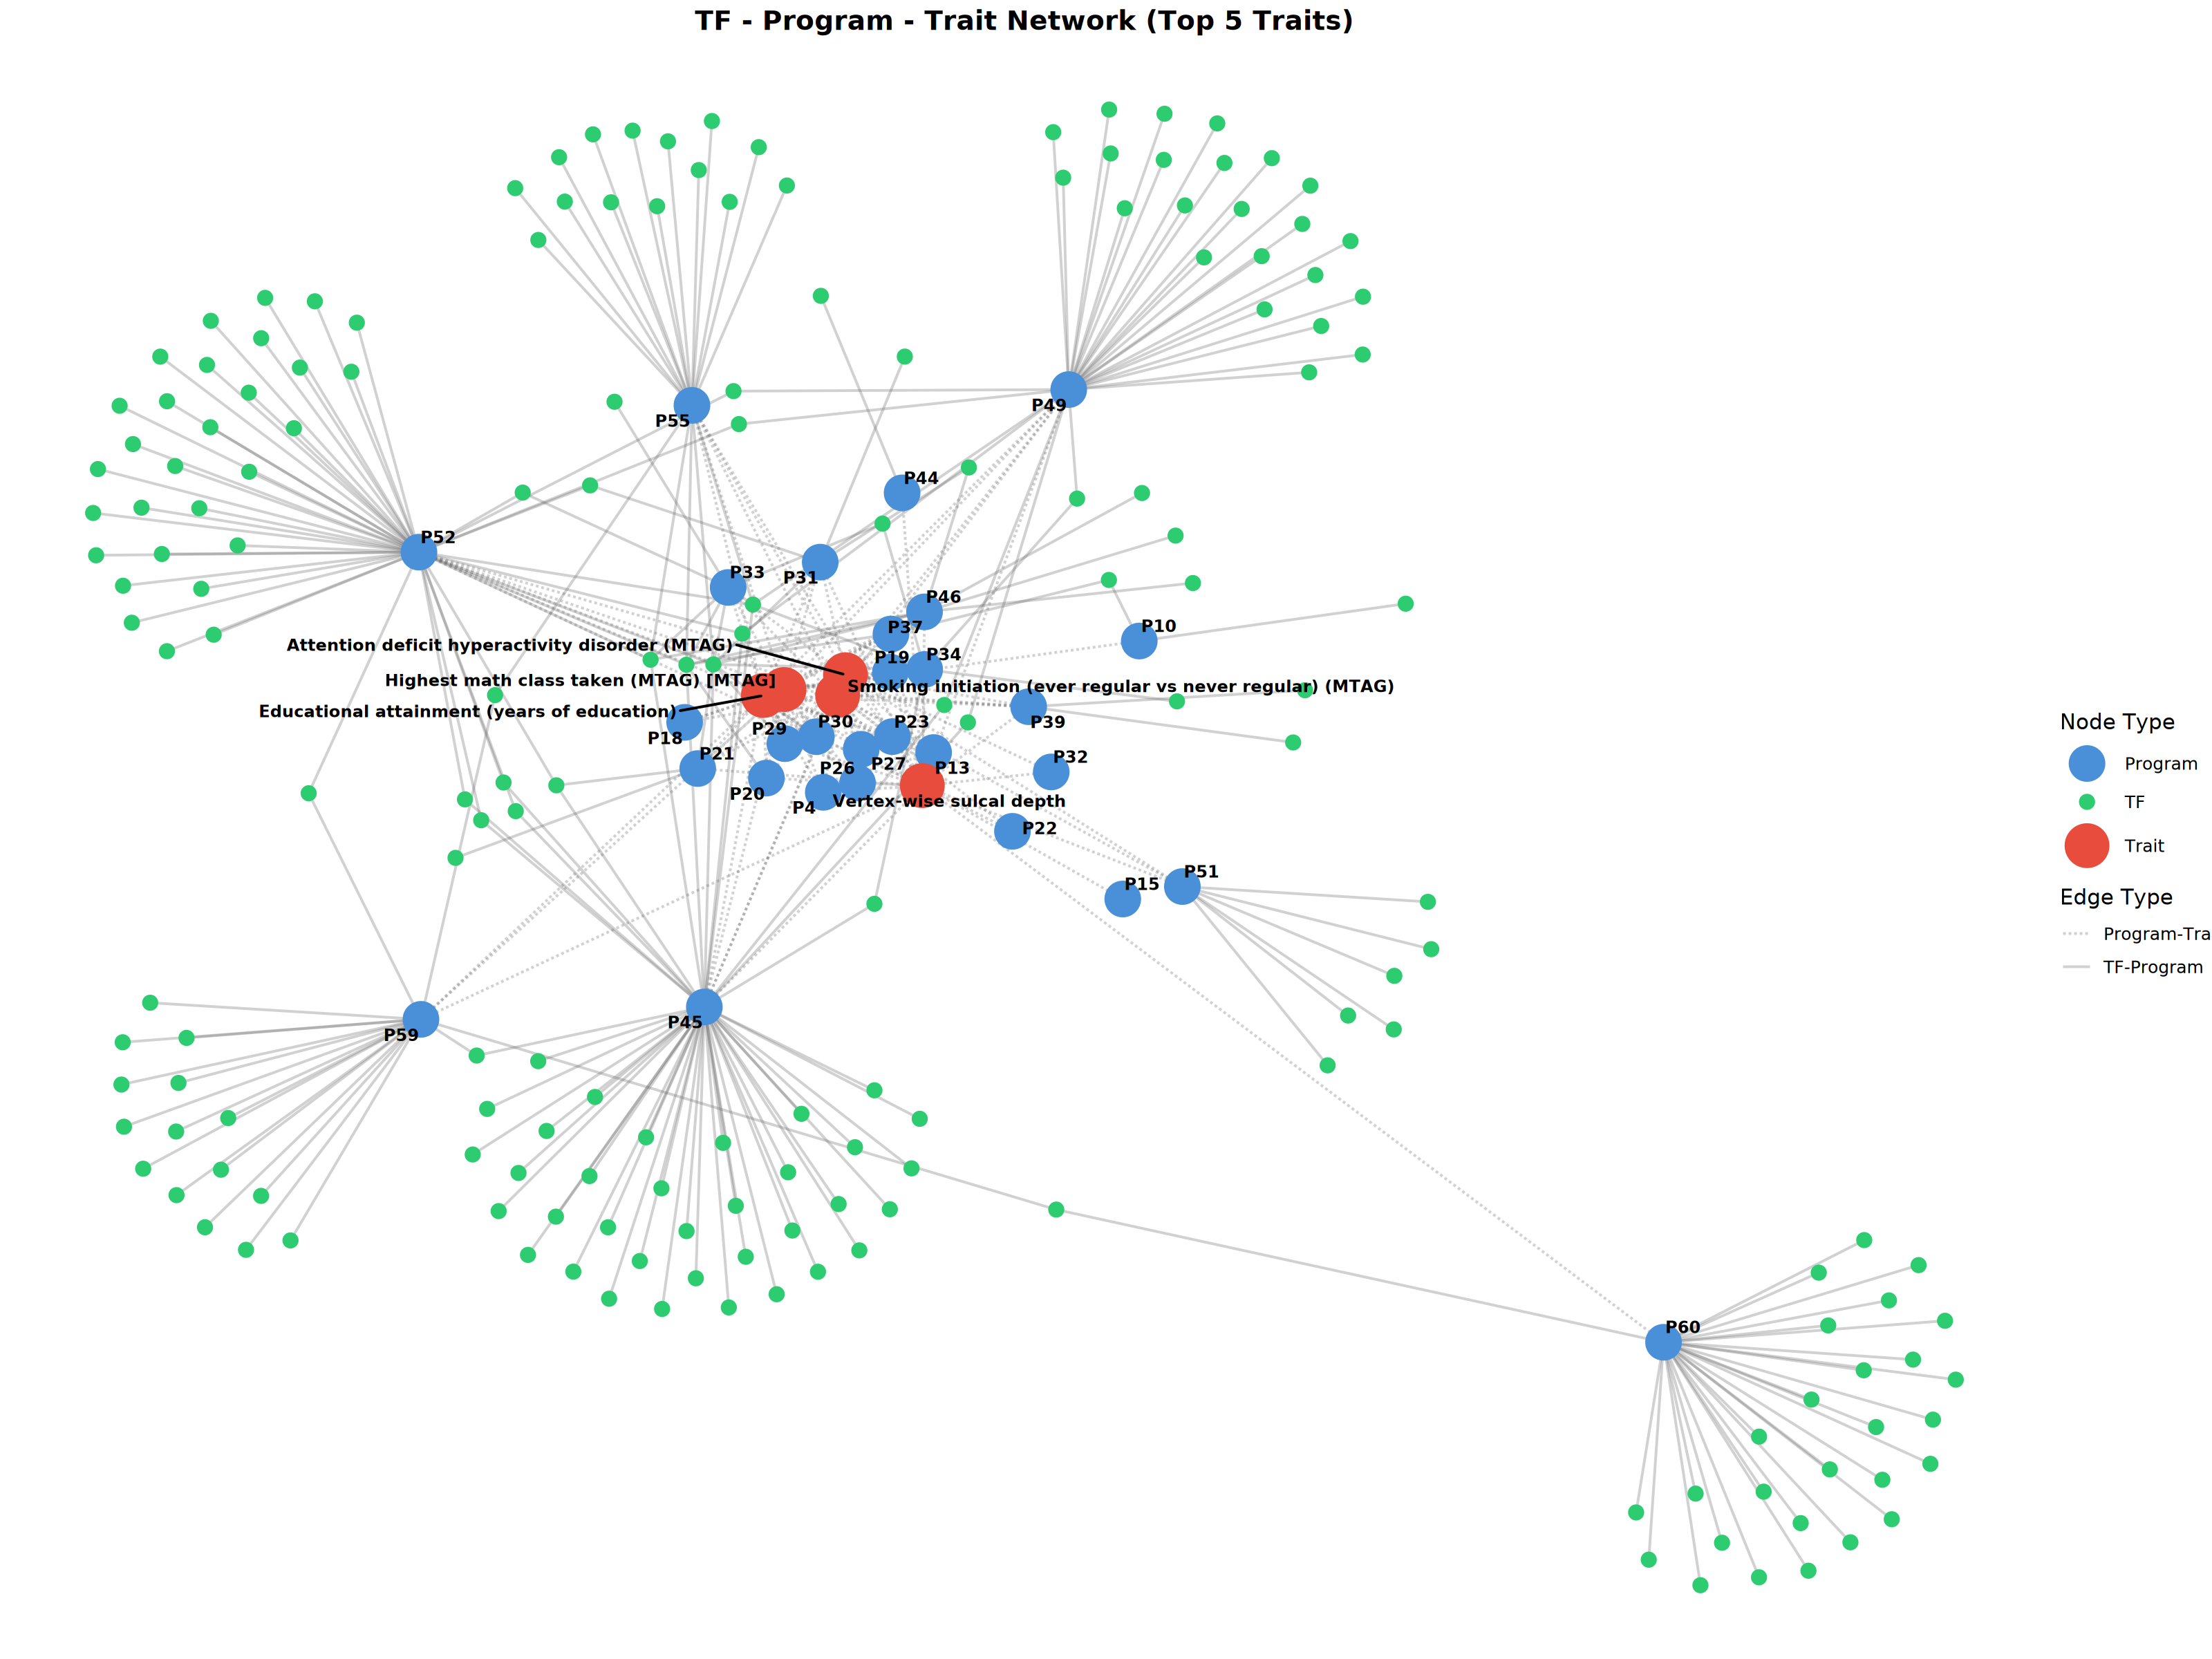

In [3]:

# Filter for significant edges: adj_pval < 0.01 and |log2FC| > 0.5
sig_perturb <- perturb_df %>%
    filter(adj_pval < 0.01, abs(log2FC) > 0.5) %>%
    arrange(adj_pval)

cat("Significant edges:", nrow(sig_perturb), "\n")
cat("Unique TFs:", n_distinct(sig_perturb$target_name), "\n")
cat("Unique programs:", n_distinct(sig_perturb$program_label), "\n")
head(sig_perturb, 20)
# Build a term-to-label lookup by matching each EFO ID in the Term column
# trait_name_dataframe has trait_efos (single ID) and trait_reported (readable name)
trait_name_lookup <- trait_name_dataframe %>% distinct(trait_efos, trait_reported)

resolve_label <- function(term) {
    ids <- trimws(unlist(strsplit(term, ",")))
    matches <- trait_name_lookup %>% filter(trait_efos %in% ids) %>% pull(trait_reported) %>% unique()
    if (length(matches) == 0) return(term)
    paste(matches, collapse = " / ")
}

# Create lookup for all terms
all_terms <- unique(trait_dataframe$Term)
term_labels <- sapply(all_terms, resolve_label, USE.NAMES = TRUE)
term_label_df <- data.frame(Term = names(term_labels), trait_label = unname(term_labels), stringsAsFactors = FALSE)

# Pick top 5 traits by minimum P-value
top5_traits <- trait_dataframe %>%
    group_by(Term) %>%
    summarise(min_p = min(P.value)) %>%
    slice_min(min_p, n = 5) %>%
    pull(Term)

# Get readable labels for top 5
top5_labels <- term_label_df %>% filter(Term %in% top5_traits)
cat("Top 5 traits:\n")
cat(paste(top5_labels$Term, "->", top5_labels$trait_label), sep = "\n")

# Trait-program edges for top 5 traits, with readable labels
trait_edges <- trait_dataframe %>%
    filter(Term %in% top5_traits, P.value < 0.05) %>%
    left_join(term_label_df, by = "Term") %>%
    mutate(from = paste0("P", program_name), to = trait_label,
           edge_type = "Program-Trait") %>%
    select(from, to, edge_type)

# Get the programs connected to these traits
linked_programs <- unique(trait_edges$from)

# TF-program edges for those programs
tf_edges <- sig_perturb %>%
    filter(program_label %in% linked_programs) %>%
    mutate(from = target_name, to = program_label,
           edge_type = "TF-Program") %>%
    select(from, to, edge_type)

cat("\n\nTrait-Program edges:", nrow(trait_edges))
cat("\nTF-Program edges:", nrow(tf_edges))

# Combine edges
all_edges <- bind_rows(trait_edges, tf_edges)

# Build graph
g <- graph_from_data_frame(all_edges, directed = FALSE)

# Classify node types: trait labels from top5
trait_node_names <- unique(trait_edges$to)
V(g)$type <- case_when(
    V(g)$name %in% trait_node_names ~ "Trait",
    grepl("^P\\d+$", V(g)$name) ~ "Program",
    TRUE ~ "TF"
)
options(repr.plot.width = 13, repr.plot.height = 8, repr.plot.res = 200)

# Convert to tbl_graph
tg <- as_tbl_graph(g)

options(repr.plot.width = 16, repr.plot.height = 12)

ggraph(tg, layout = "fr") +
    geom_edge_link(aes(linetype = edge_type), alpha = 0.3, color = "grey40") +
    scale_edge_linetype_manual(values = c("TF-Program" = "solid", "Program-Trait" = "dashed"),
                                name = "Edge Type") +
    geom_node_point(aes(color = type, size = type)) +
    scale_color_manual(values = c("TF" = "#2ECC71", "Program" = "#4A90D9", "Trait" = "#E74C3C"),
                       name = "Node Type") +
    scale_size_manual(values = c("TF" = 3, "Program" = 8, "Trait" = 10),
                      name = "Node Type") +
    geom_node_text(
        aes(label = ifelse(type != "TF", name, "")),
        repel = TRUE, size = 3, max.overlaps = 30, fontface = "bold"
    ) +
    theme_void() +
    labs(title = "TF - Program - Trait Network (Top 5 Traits)") +
    theme(
        plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
        legend.position = "right"
    )

In [4]:
# Search for endoderm-relevant traits in the lookup table
endoderm_keywords <- c("liver", "hepat", "pancrea", "diabet", "insulin", "glucose",
                        "gallbladder", "bile", "cholesterol", "lipid", "triglyceride",
                        "thyroid", "lung", "respiratory", "intestin", "colon", "gut",
                        "gastro", "stomach", "esophag", "digestive", "metaboli",
                        "glycem", "HbA1c", "NAFLD", "cirrhosis", "steatosis",
                        "inflammatory bowel", "crohn", "colitis", "celiac",
                        "endoderm", "foregut", "hindgut", "midgut")

pattern <- paste(endoderm_keywords, collapse = "|")

endoderm_traits <- term_label_df %>%
    filter(grepl(pattern, trait_label, ignore.case = TRUE)) %>%
    arrange(trait_label)

cat("Found", nrow(endoderm_traits), "endoderm-relevant traits:\n\n")
for (i in seq_len(nrow(endoderm_traits))) {
    cat(endoderm_traits$Term[i], " -> ", endoderm_traits$trait_label[i], "\n")
}

Found 64 endoderm-relevant traits:

EFO_0006812  ->  Autoimmune thyroid disease 
EFO_0000280  ->  Barrett's esophagus 
MONDO_0002278  ->  Benign neoplasm of colon 
EFO_0004887  ->  Cardiorespiratory fitness (vo2 max) 
EFO_0009184  ->  Cardiorespiratory fitness slope 
EFO_0001060  ->  Celiac disease 
EFO_0001060, HP_0002024  ->  Celiac disease 
EFO_0009433  ->  Chronic lower respiratory diseases 
MONDO_0021400  ->  Colon polyp 
EFO_0000400  ->  Diabetes, varying definitions 
EFO_1000627  ->  Disorders of the thyroid gland 
EFO_0004232  ->  Eosinophilic esophagitis 
EFO_0004465  ->  Fasting glucose 
EFO_0004466  ->  Fasting insulin 
EFO_0004467  ->  Fasting insulin 
EFO_0003832  ->  Gallbladder disease 
EFO_0003948  ->  Gastroesophageal reflux disease 
EFO_0004468  ->  Glucose levels 
EFO_0004612  ->  HDL cholesterol levels 
HP_0003124  ->  High cholesterol 
EFO_0009189  ->  Hyperthyroidism 
EFO_0004705  ->  Hypothyroidism 
EFO_0003779  ->  Hypothyroidism, strict autoimmune, 3 medication

In [5]:
# Rank endoderm traits by number of significantly associated programs (P < 0.05)
endoderm_ranked <- trait_dataframe %>%
    filter(Term %in% endoderm_traits$Term, P.value < 0.05) %>%
    group_by(Term) %>%
    summarise(n_programs = n_distinct(program_name),
              min_pval = min(P.value),
              programs = paste(sort(unique(program_name)), collapse = ", ")) %>%
    left_join(term_label_df, by = "Term") %>%
    arrange(desc(n_programs), min_pval)

cat("Endoderm traits ranked by number of associated programs (P < 0.05):\n\n")
for (i in seq_len(nrow(endoderm_ranked))) {
    cat(sprintf("%2d. [%d programs] %s\n      Programs: %s\n      Min P = %.2e\n\n",
                i, endoderm_ranked$n_programs[i], endoderm_ranked$trait_label[i],
                endoderm_ranked$programs[i], endoderm_ranked$min_pval[i]))
}

Endoderm traits ranked by number of associated programs (P < 0.05):

 1. [24 programs] Lung function (FVC)
      Programs: 4, 6, 8, 11, 19, 20, 21, 23, 25, 26, 27, 29, 30, 31, 32, 37, 39, 43, 45, 46, 51, 52, 55, 59
      Min P = 2.08e-04

 2. [11 programs] Lung function (FEV1/FVC)
      Programs: 13, 19, 21, 24, 27, 29, 30, 32, 35, 44, 52
      Min P = 3.25e-04

 3. [9 programs] Colon polyp
      Programs: 4, 20, 21, 31, 37, 39, 45, 46, 52
      Min P = 7.84e-04

 4. [9 programs] Type 2 diabetes
      Programs: 4, 13, 15, 21, 30, 31, 35, 39, 45
      Min P = 4.83e-03

 5. [8 programs] Respiratory diseases
      Programs: 14, 25, 26, 30, 31, 35, 37, 39
      Min P = 2.98e-03

 6. [8 programs] Thyroid stimulating hormone levels
      Programs: 20, 21, 26, 31, 34, 36, 45, 46
      Min P = 4.42e-03

 7. [7 programs] High cholesterol
      Programs: 13, 14, 34, 35, 36, 38, 39
      Min P = 8.91e-04

 8. [6 programs] Triglycerides
      Programs: 19, 20, 26, 31, 39, 55
      Min P = 3.81e-03

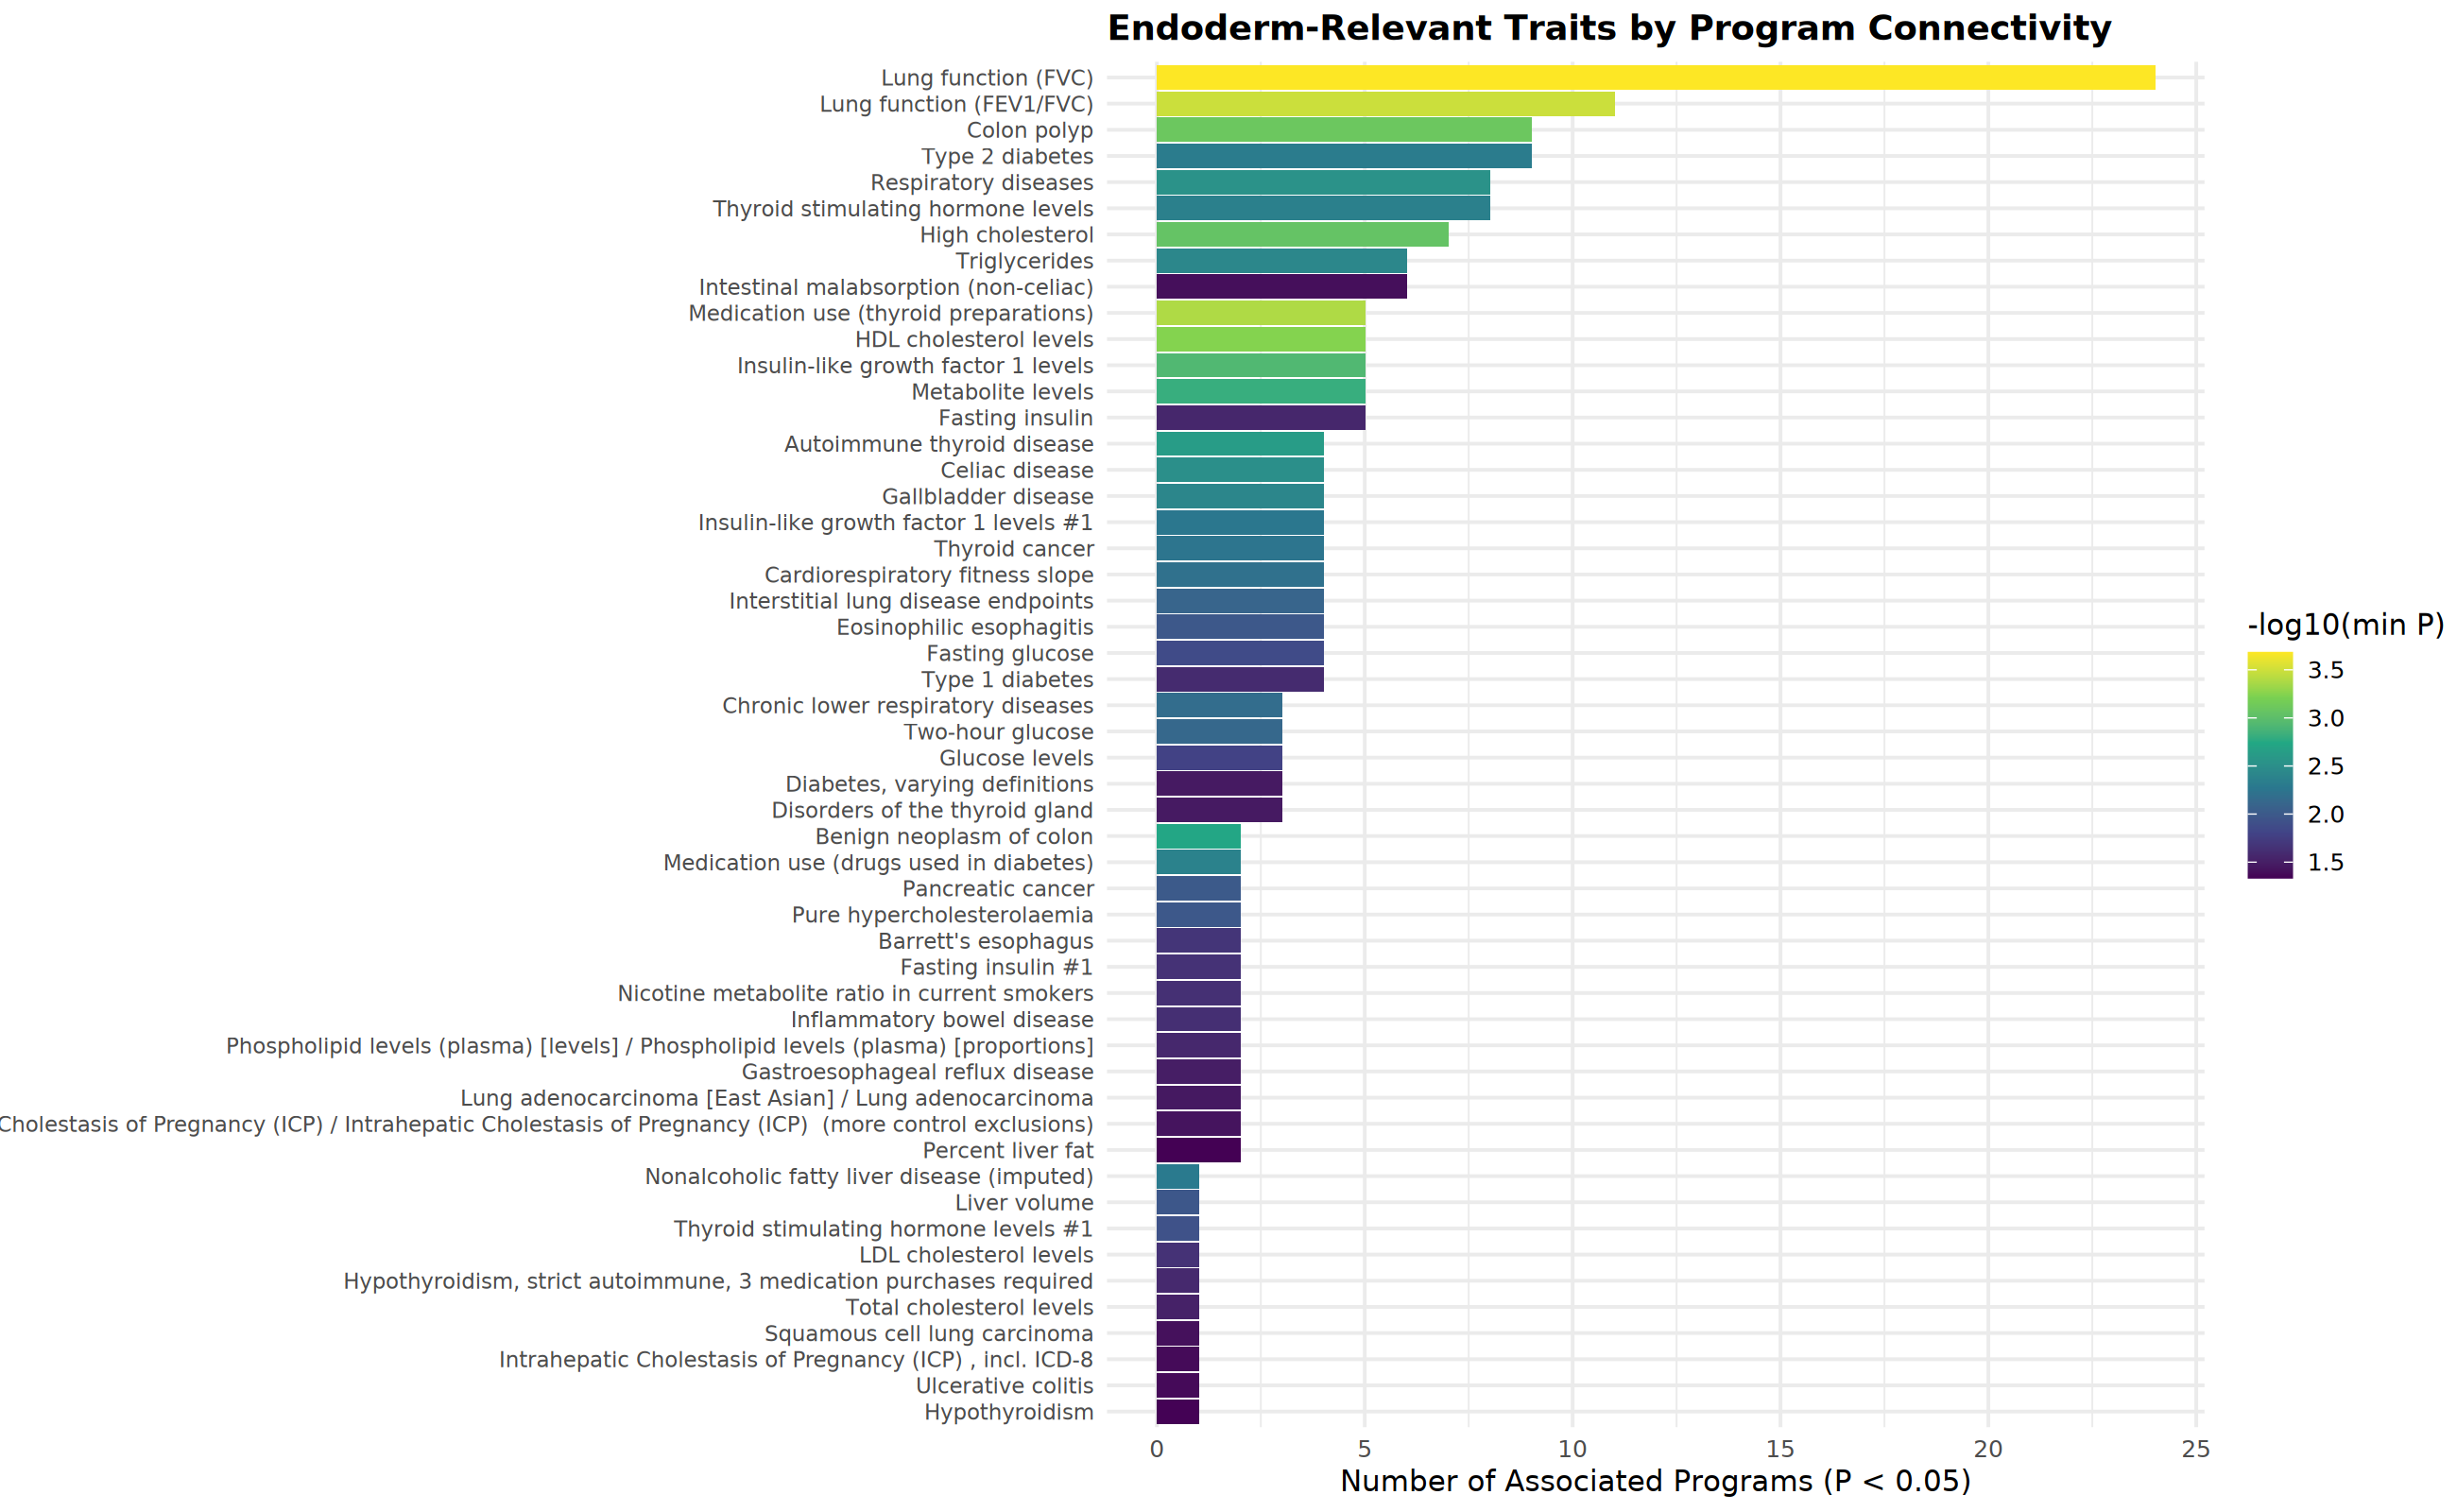

In [6]:
options(repr.plot.width = 13, repr.plot.height = 8, repr.plot.res = 200)

plot_df <- endoderm_ranked %>%
    mutate(trait_display = make.unique(trait_label, sep = " #")) %>%
    mutate(trait_display = factor(trait_display, levels = rev(trait_display)))

ggplot(plot_df, aes(x = n_programs, y = trait_display, fill = -log10(min_pval))) +
    geom_col() +
    scale_fill_viridis_c(name = "-log10(min P)") +
    labs(x = "Number of Associated Programs (P < 0.05)",
         y = NULL,
         title = "Endoderm-Relevant Traits by Program Connectivity") +
    theme_minimal() +
    theme(plot.title = element_text(face = "bold", size = 13),
          axis.text.y = element_text(size = 8))

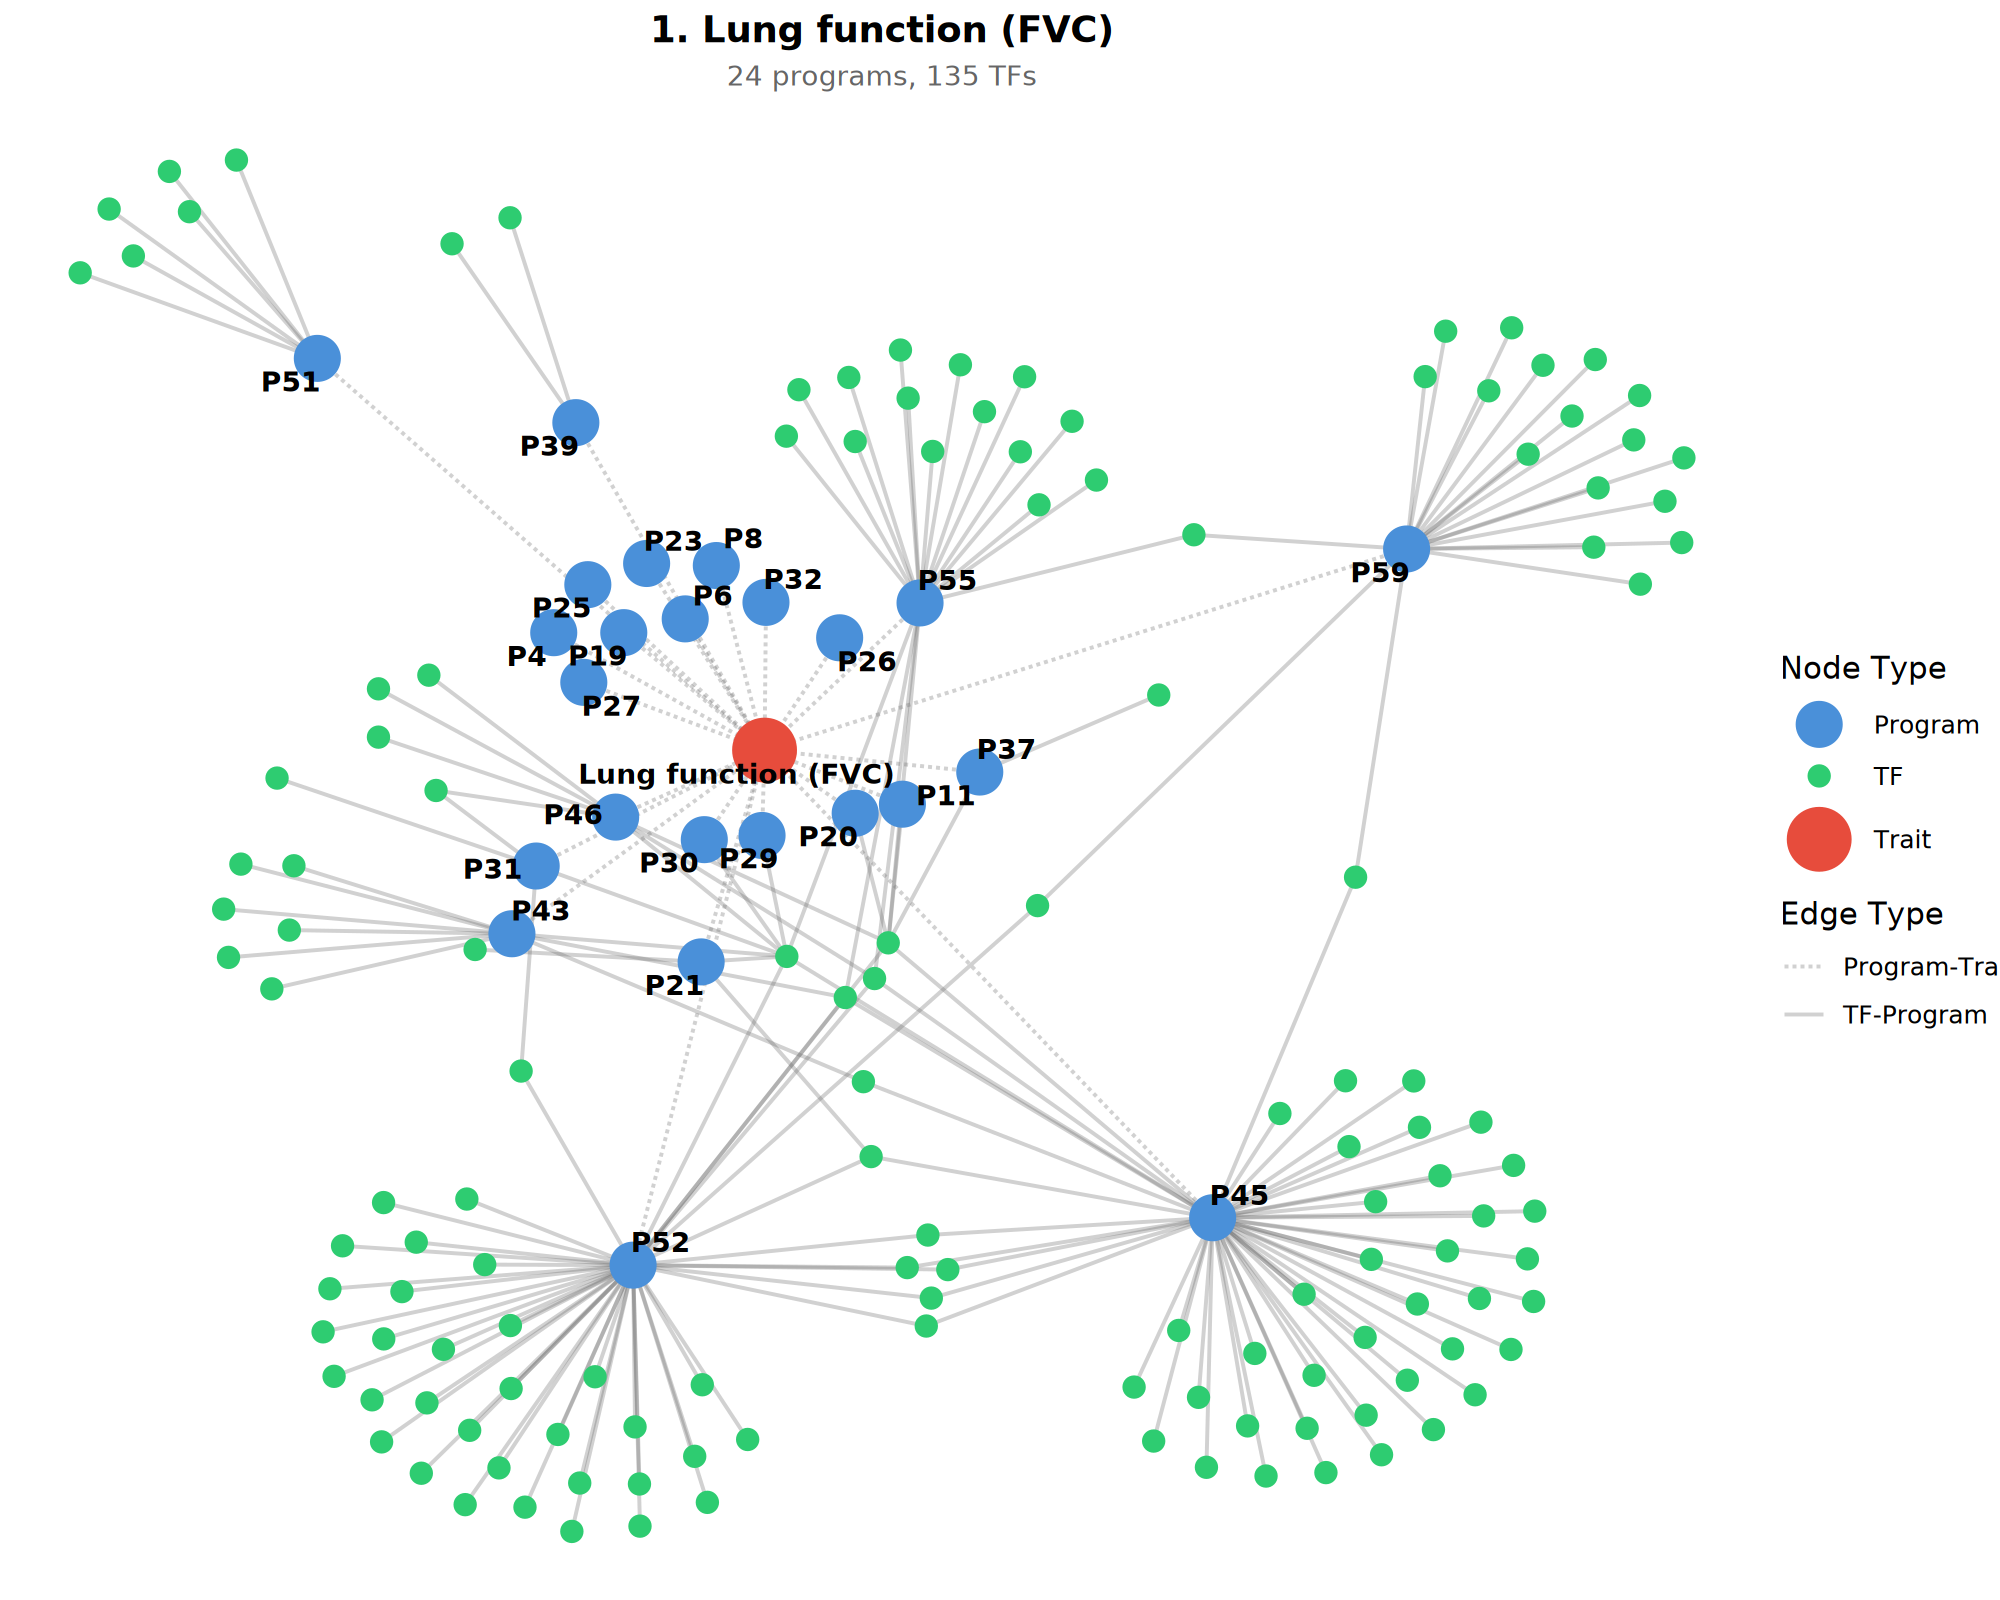

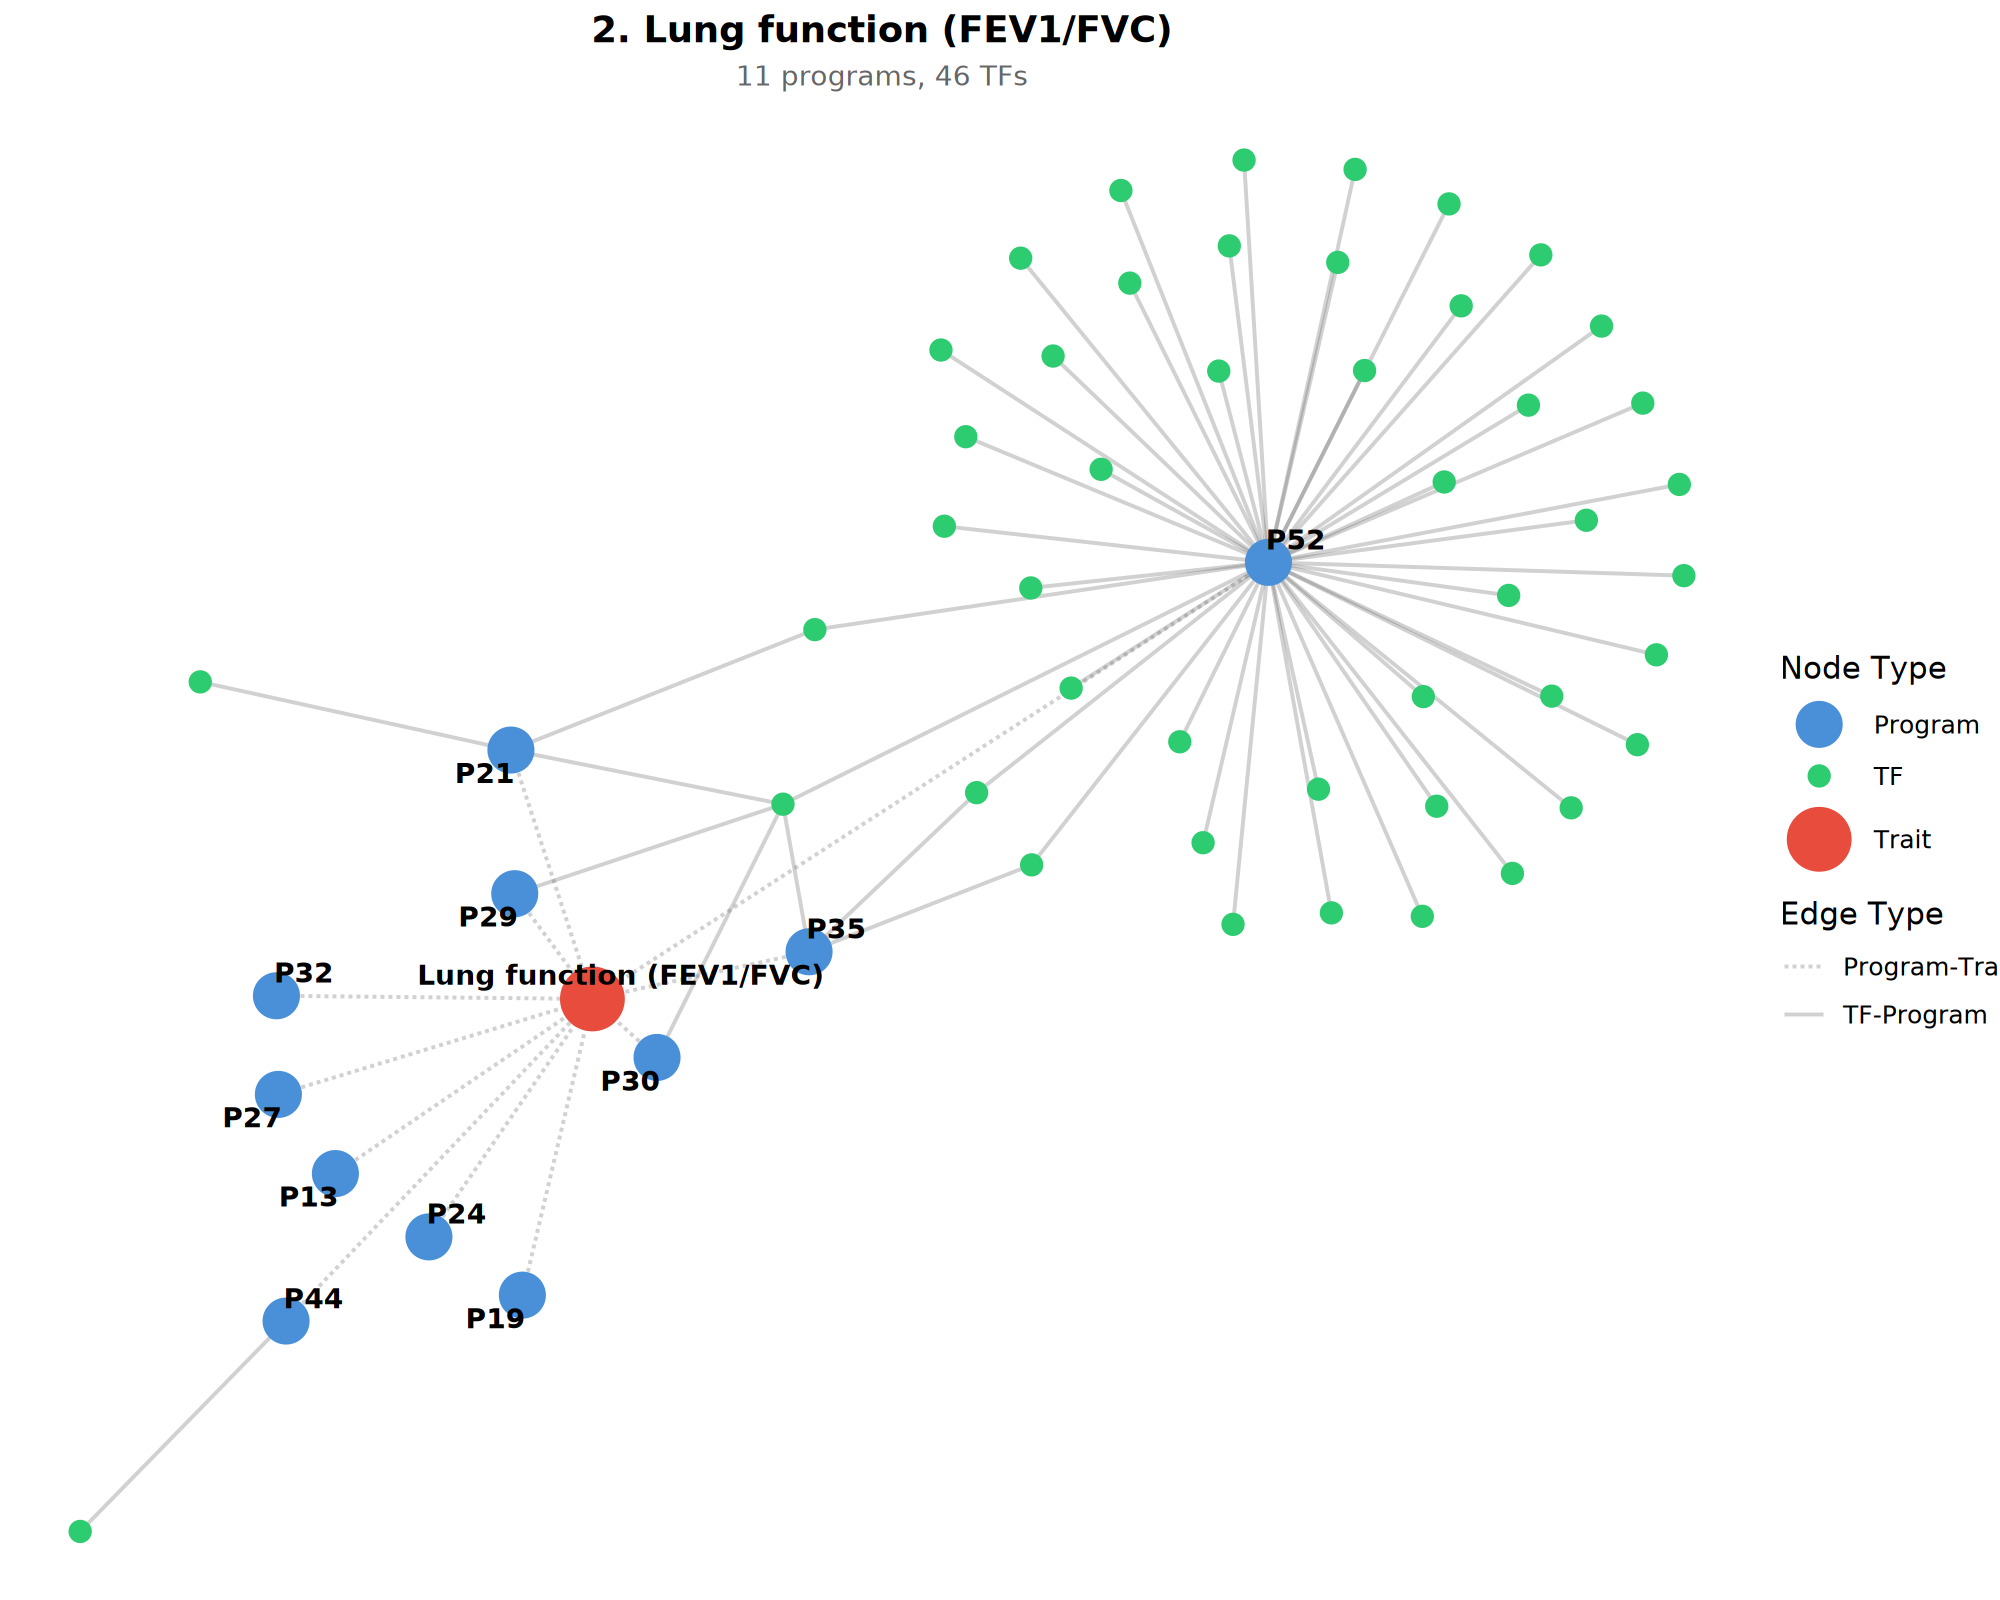

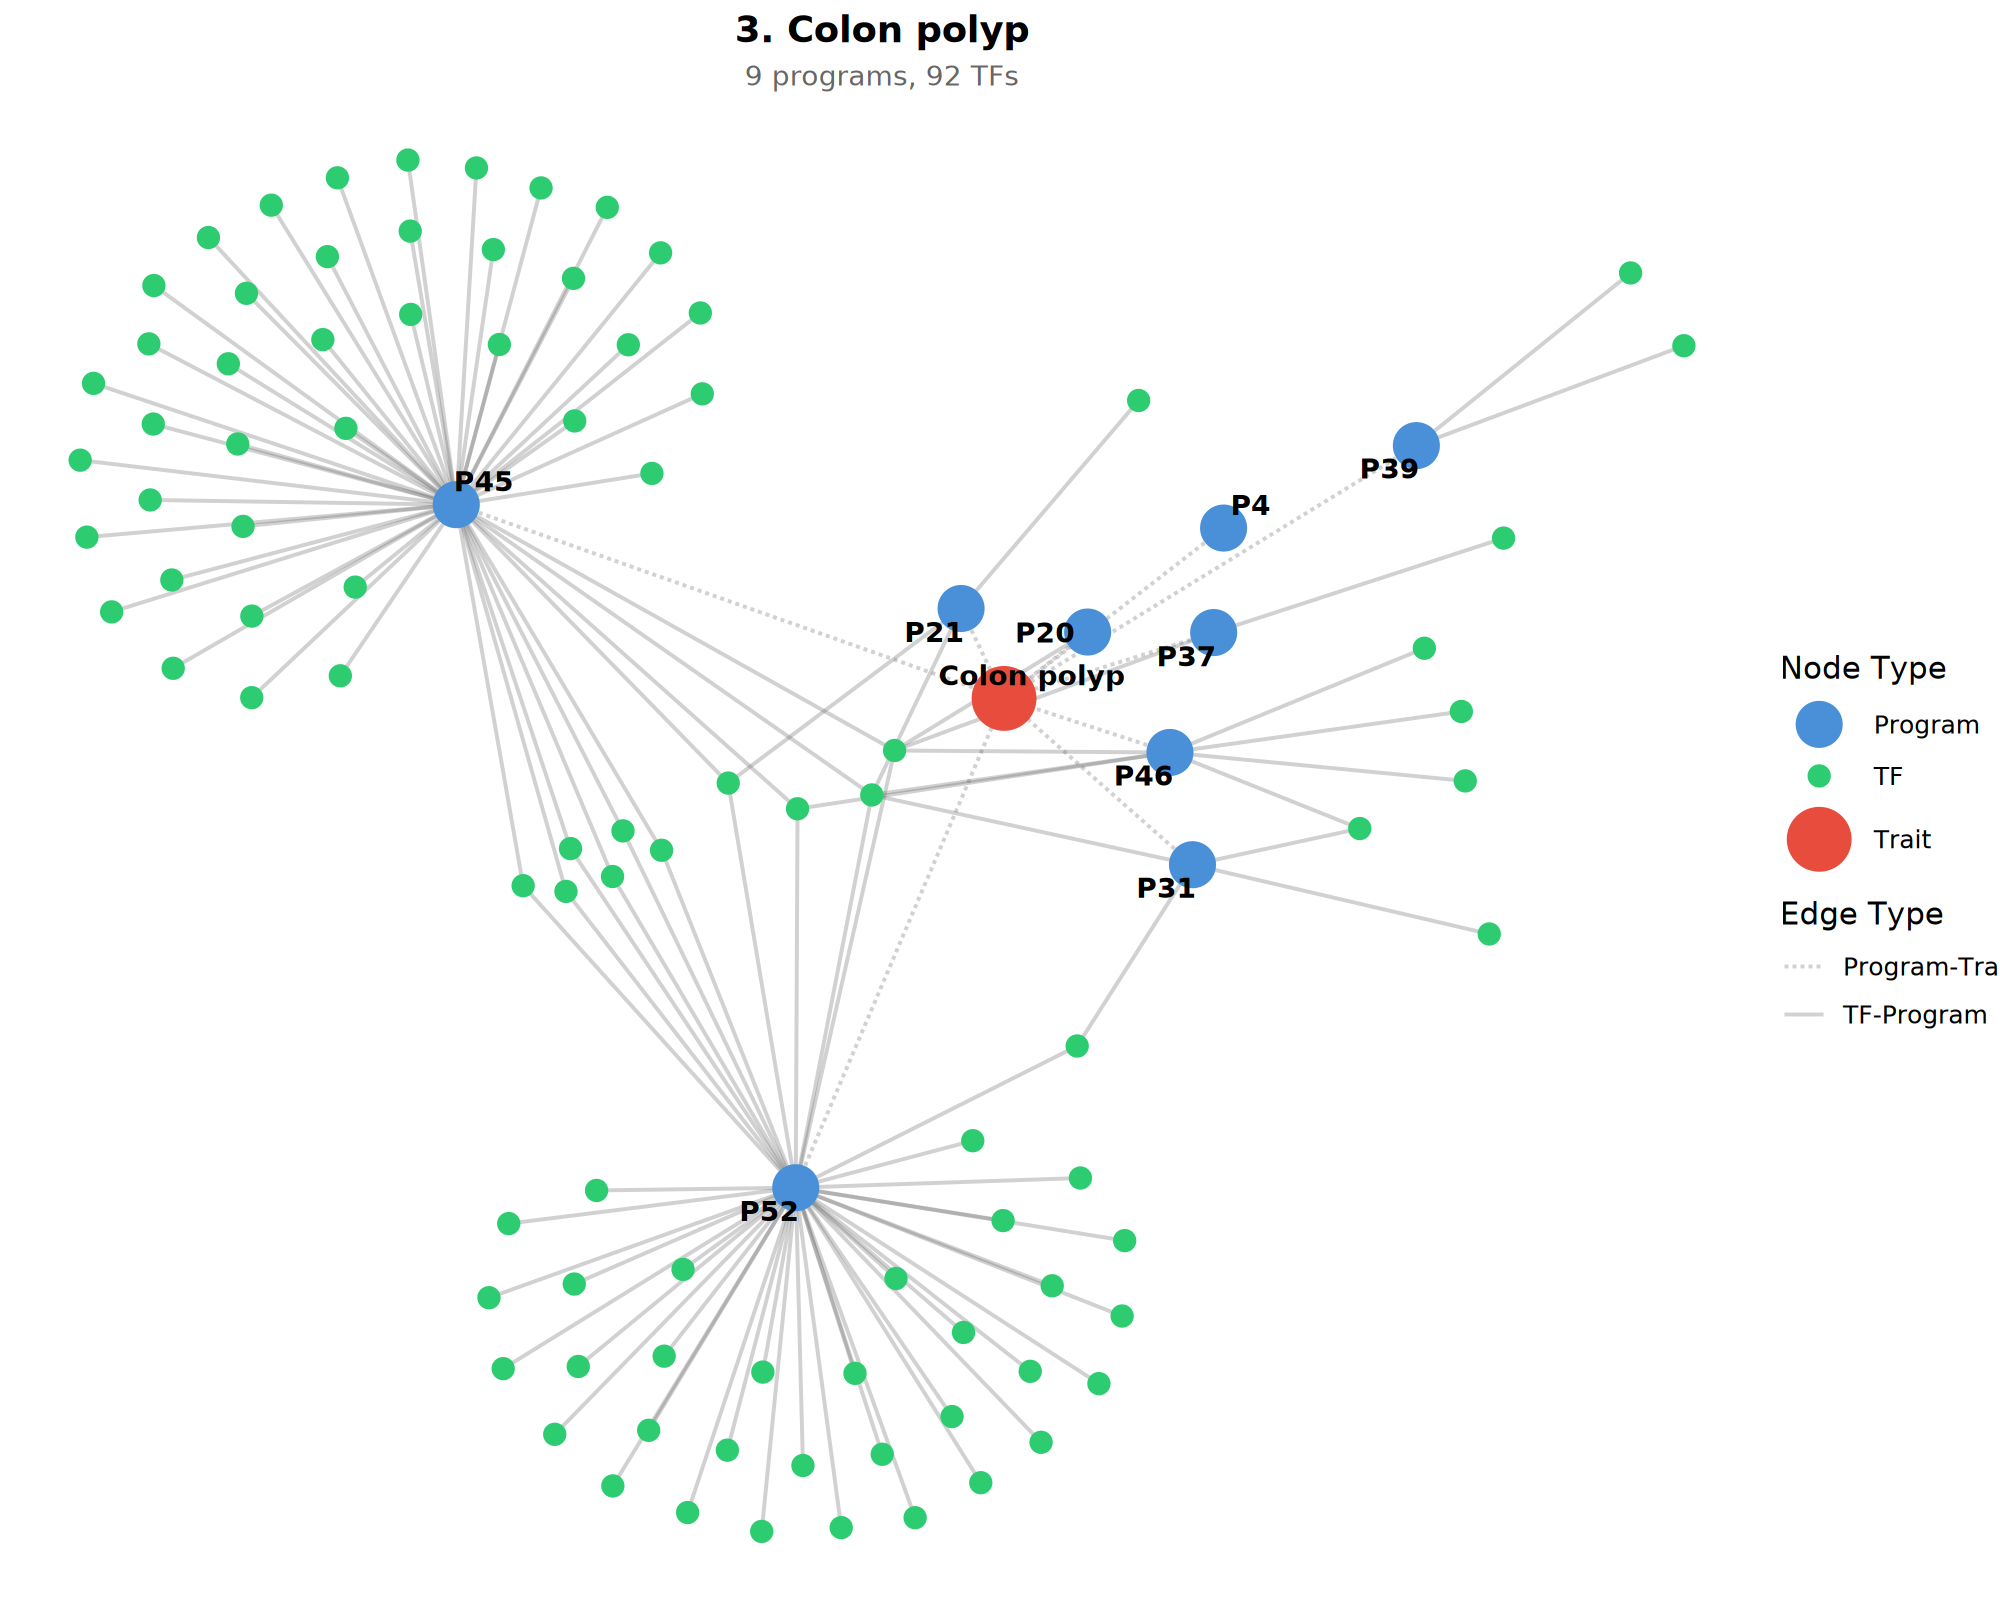

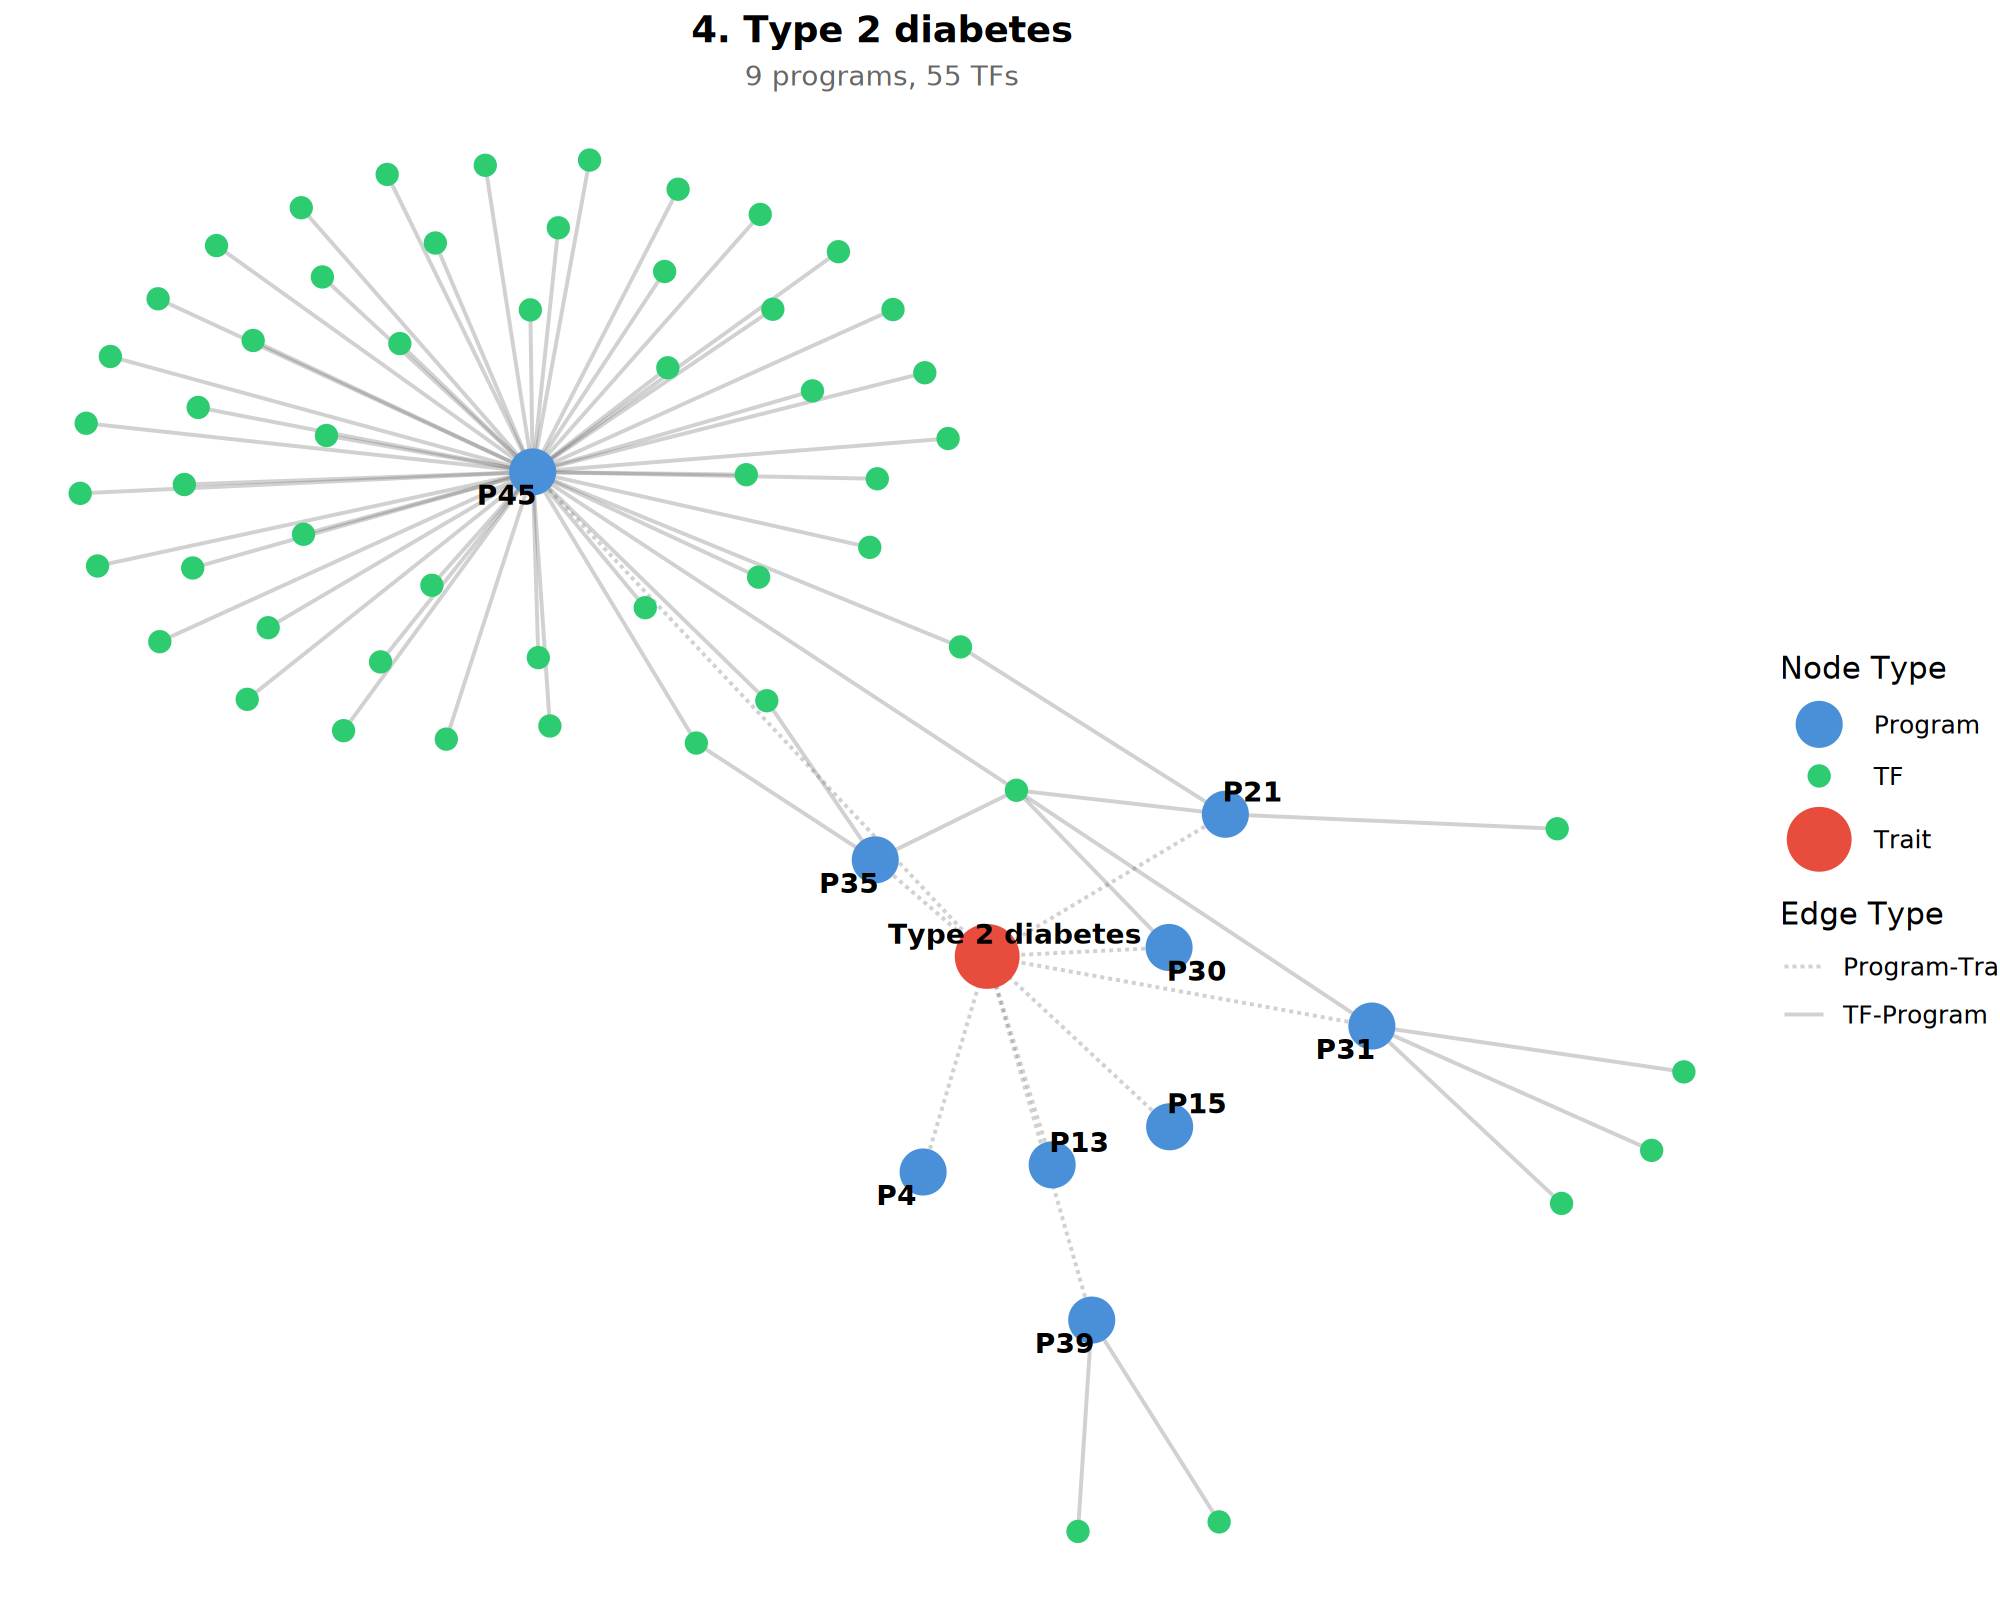

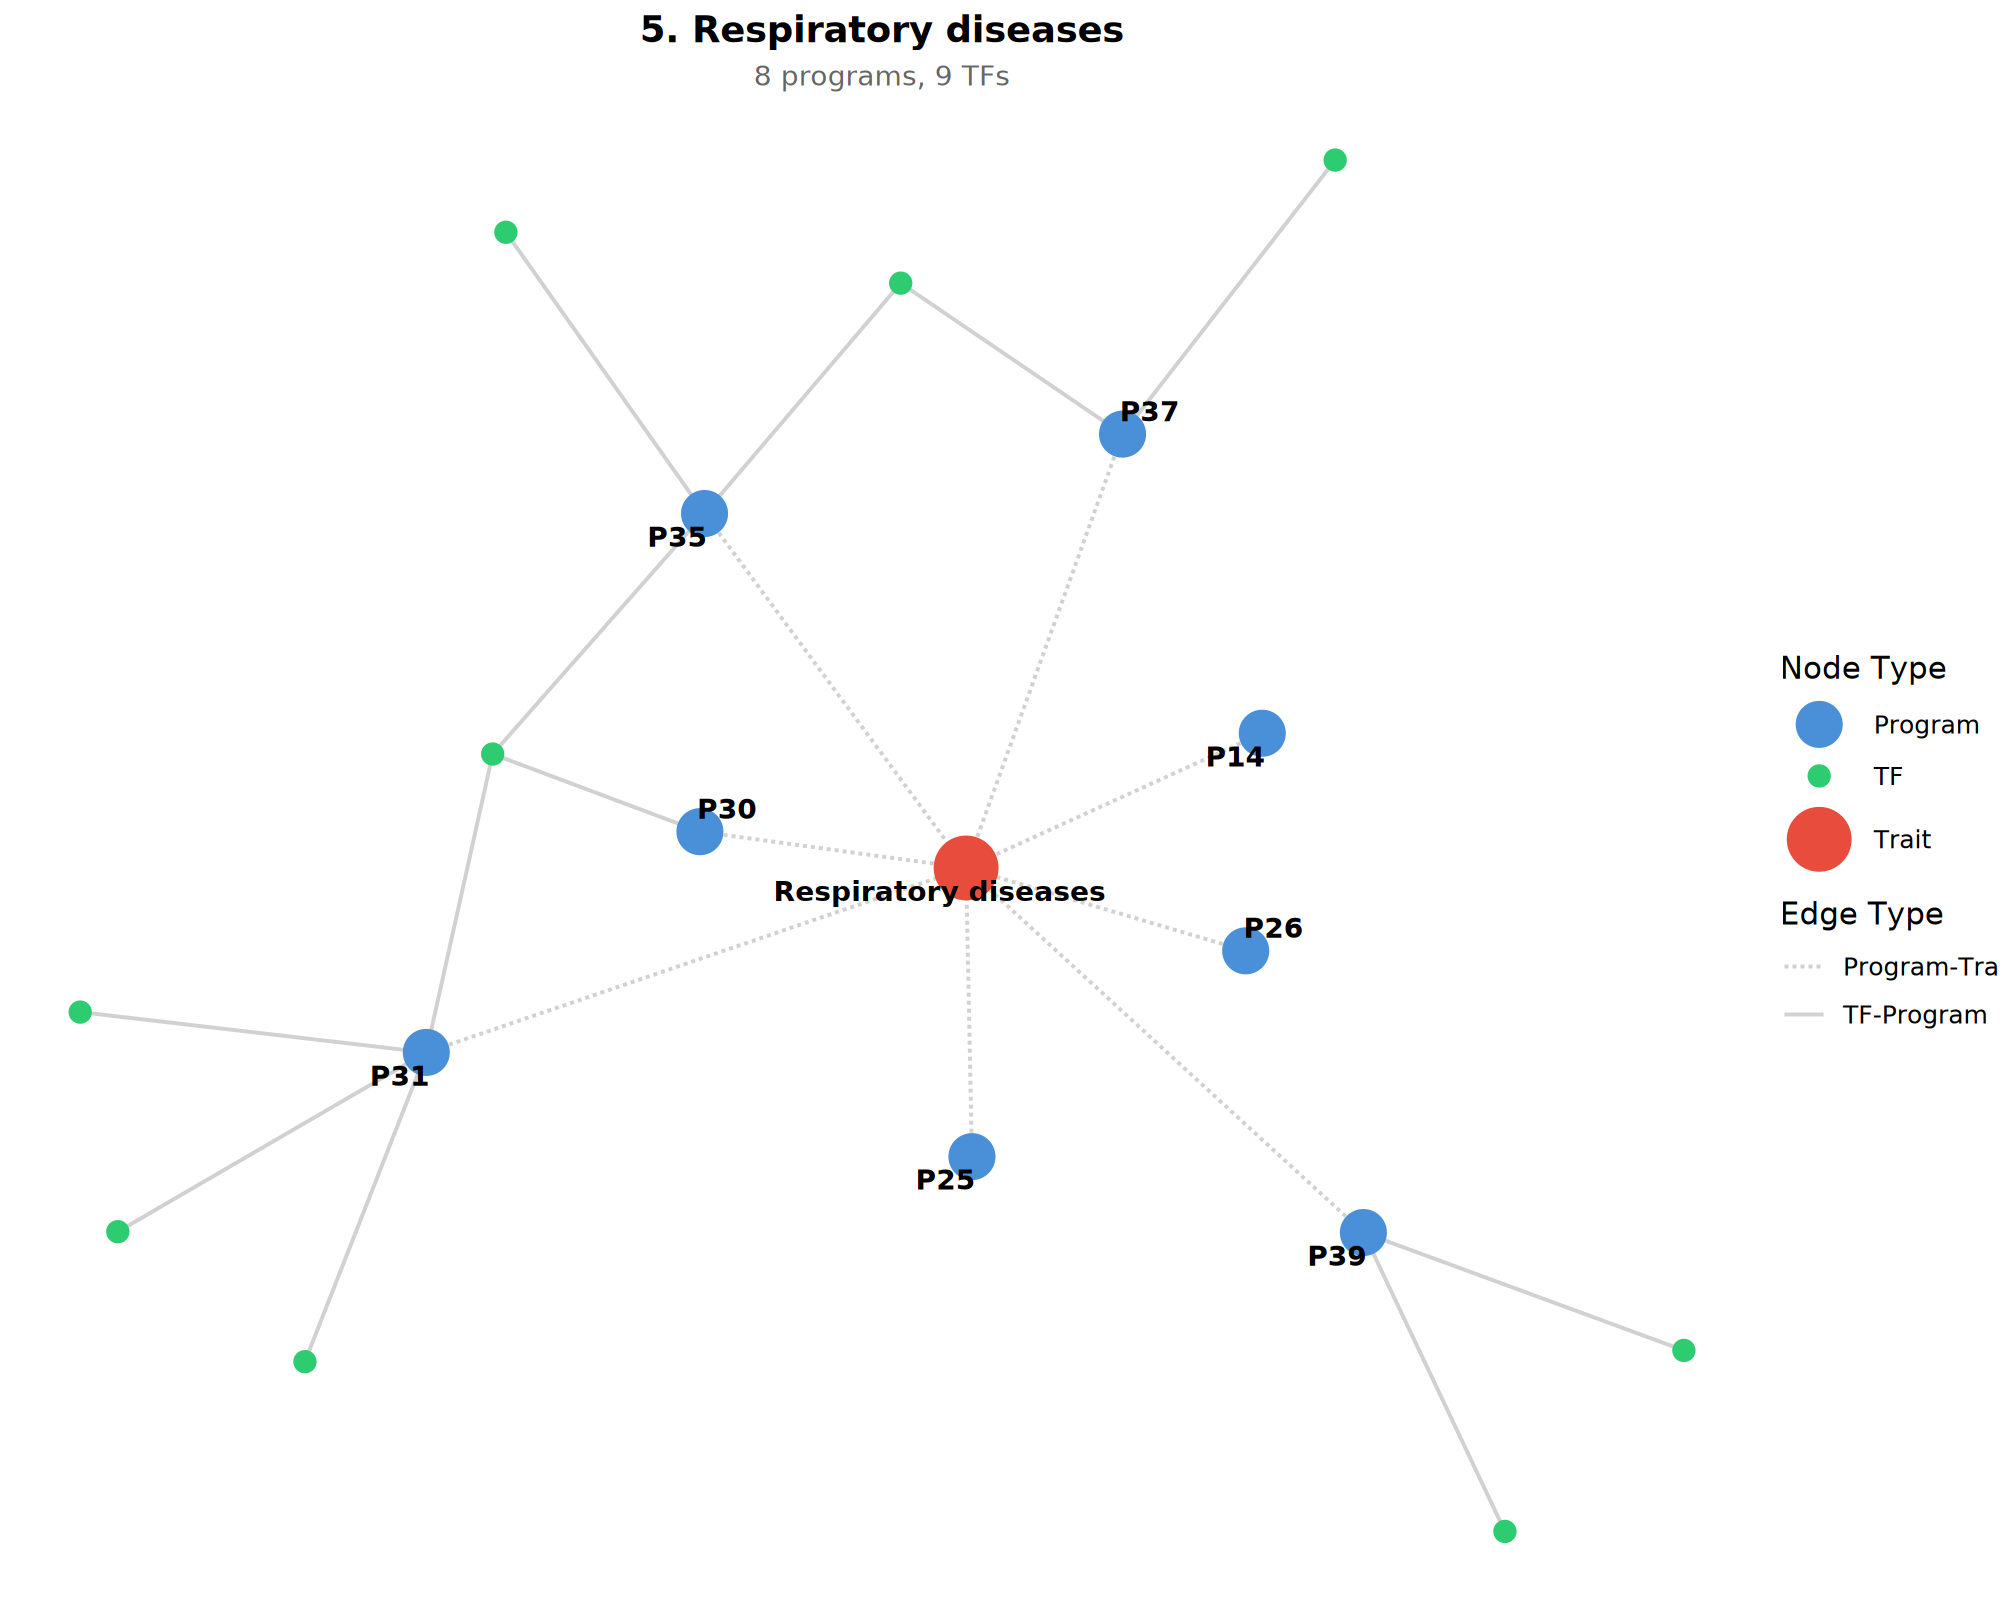

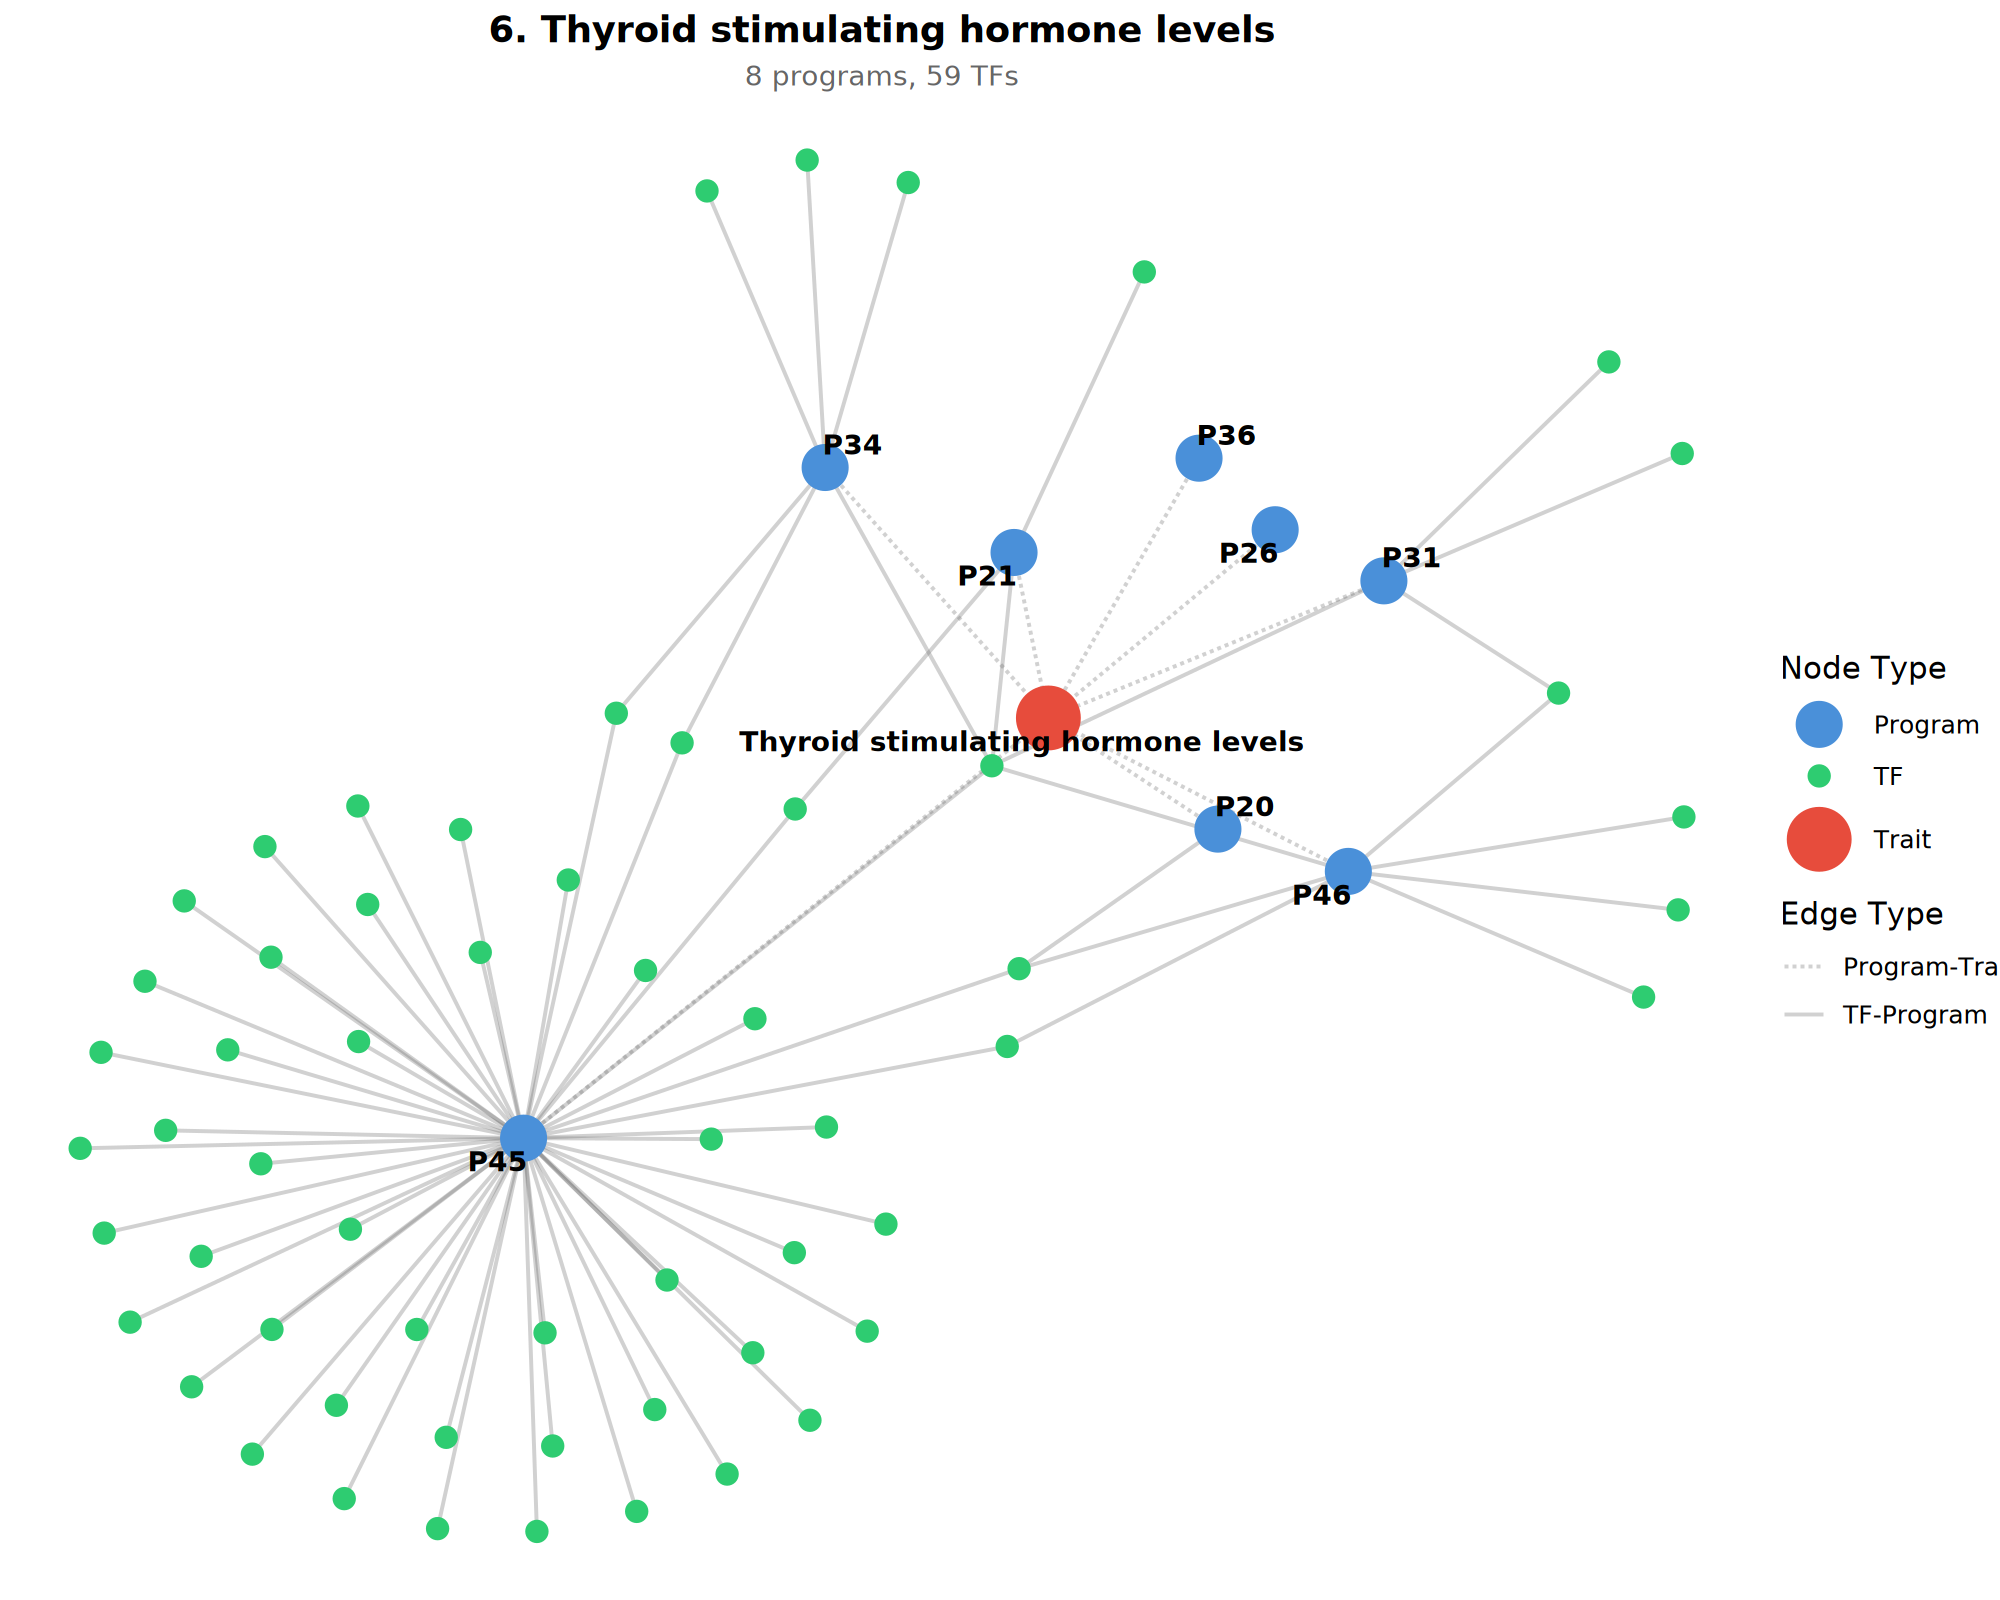

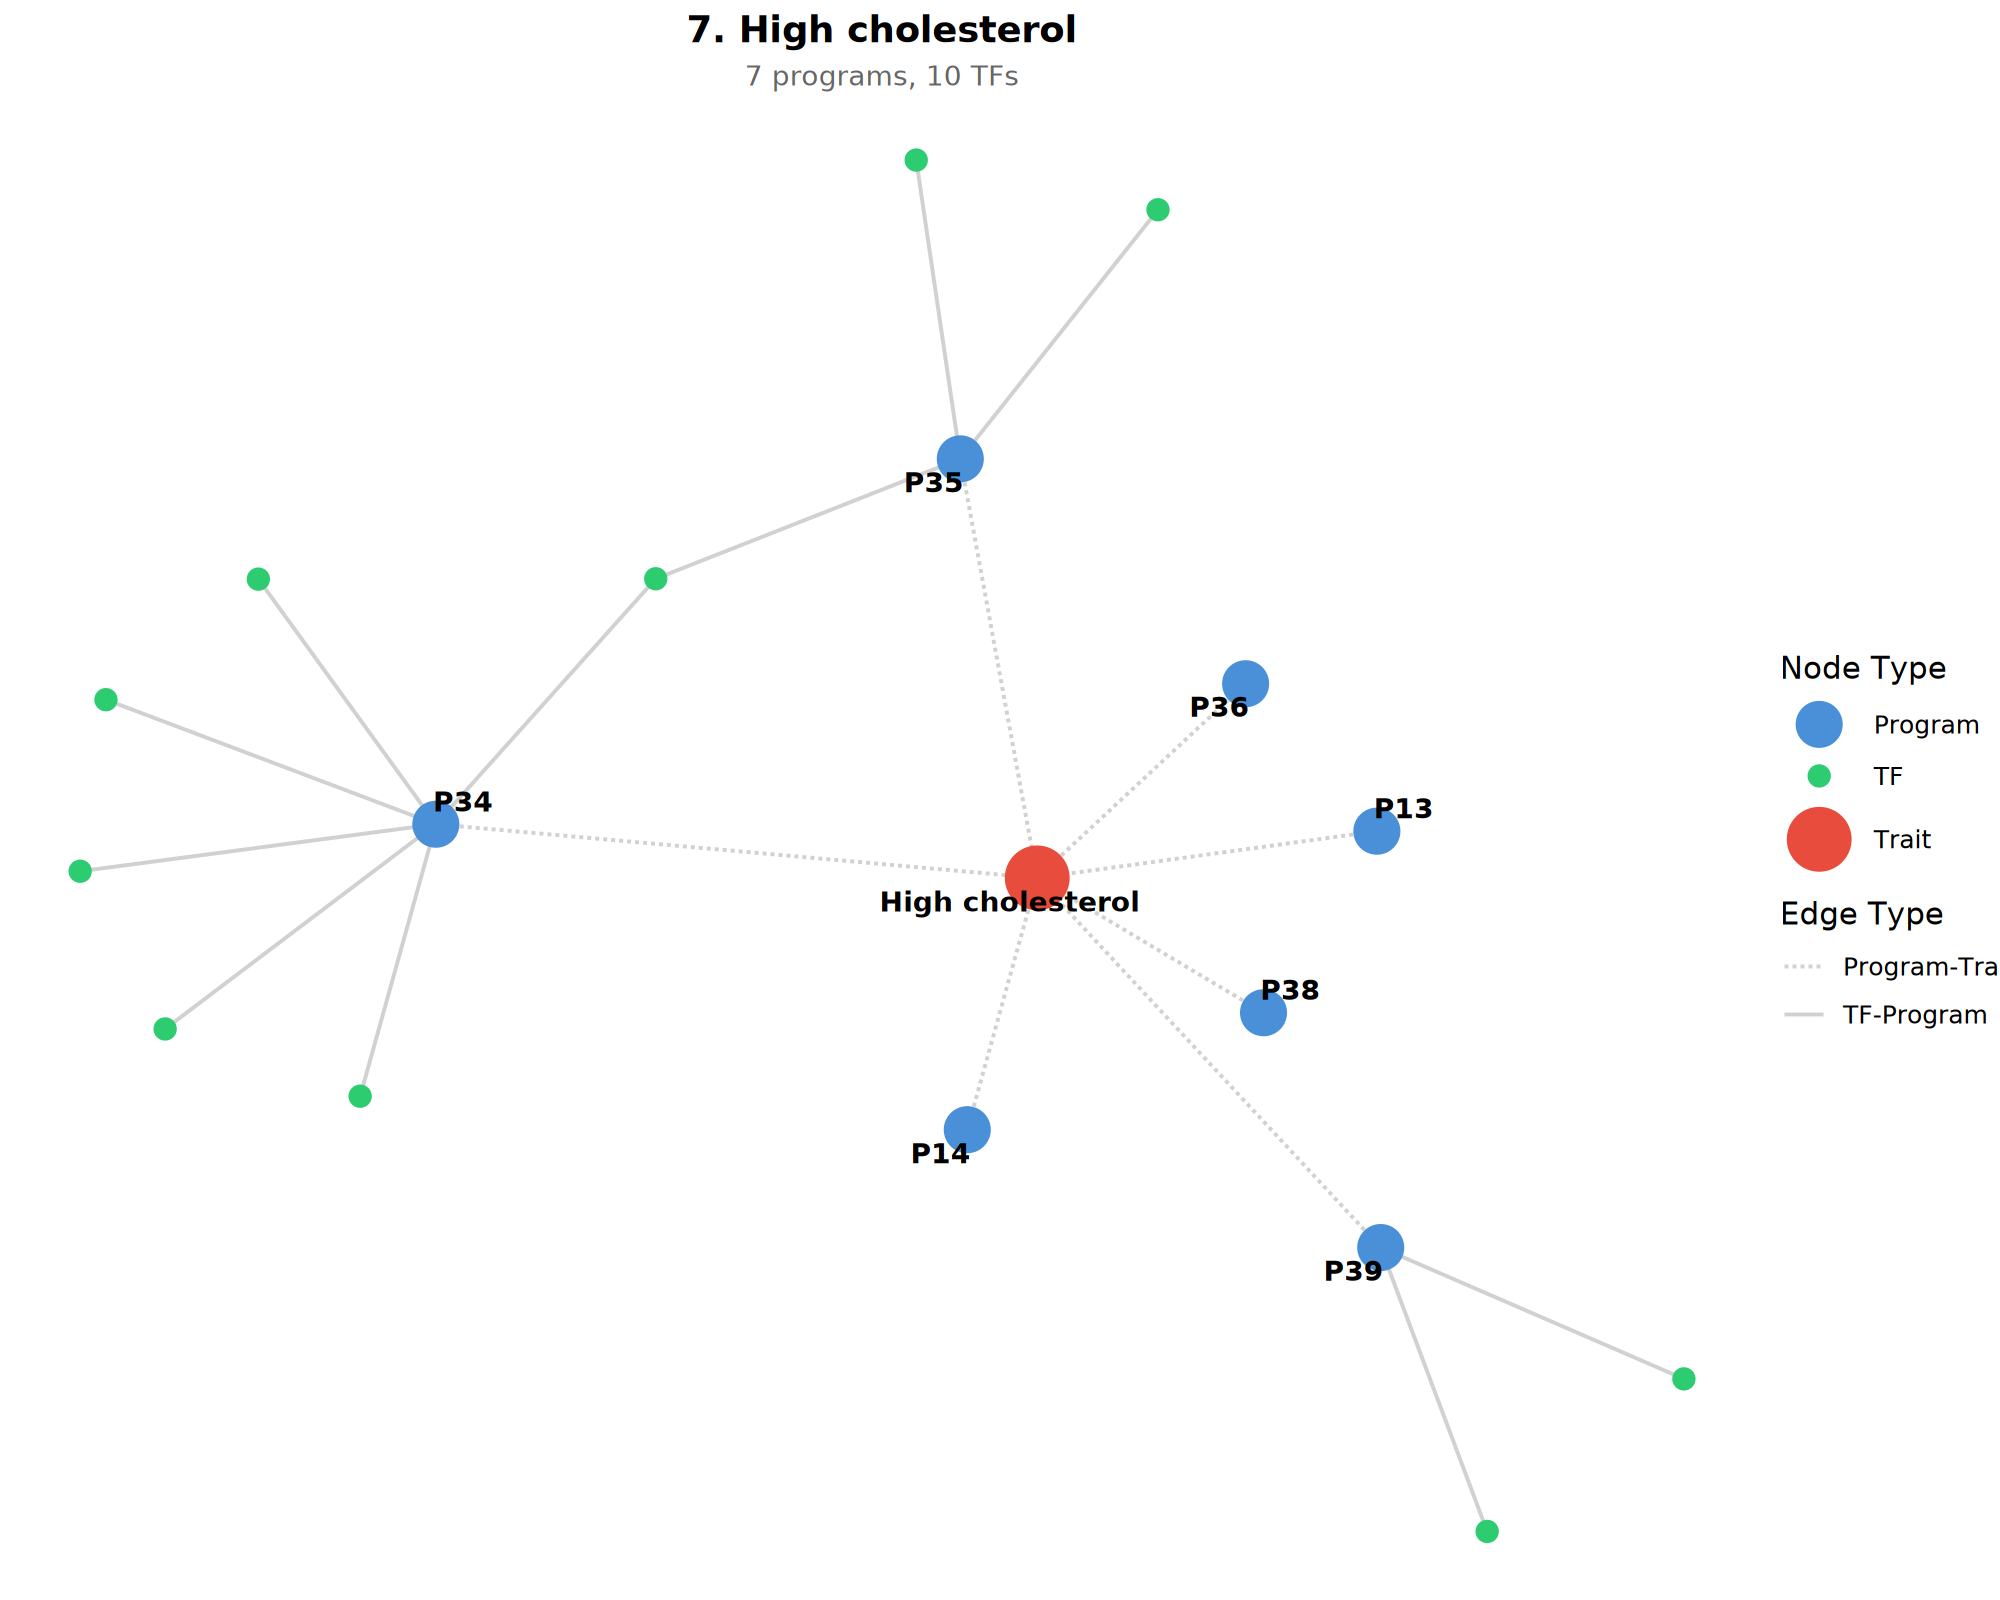

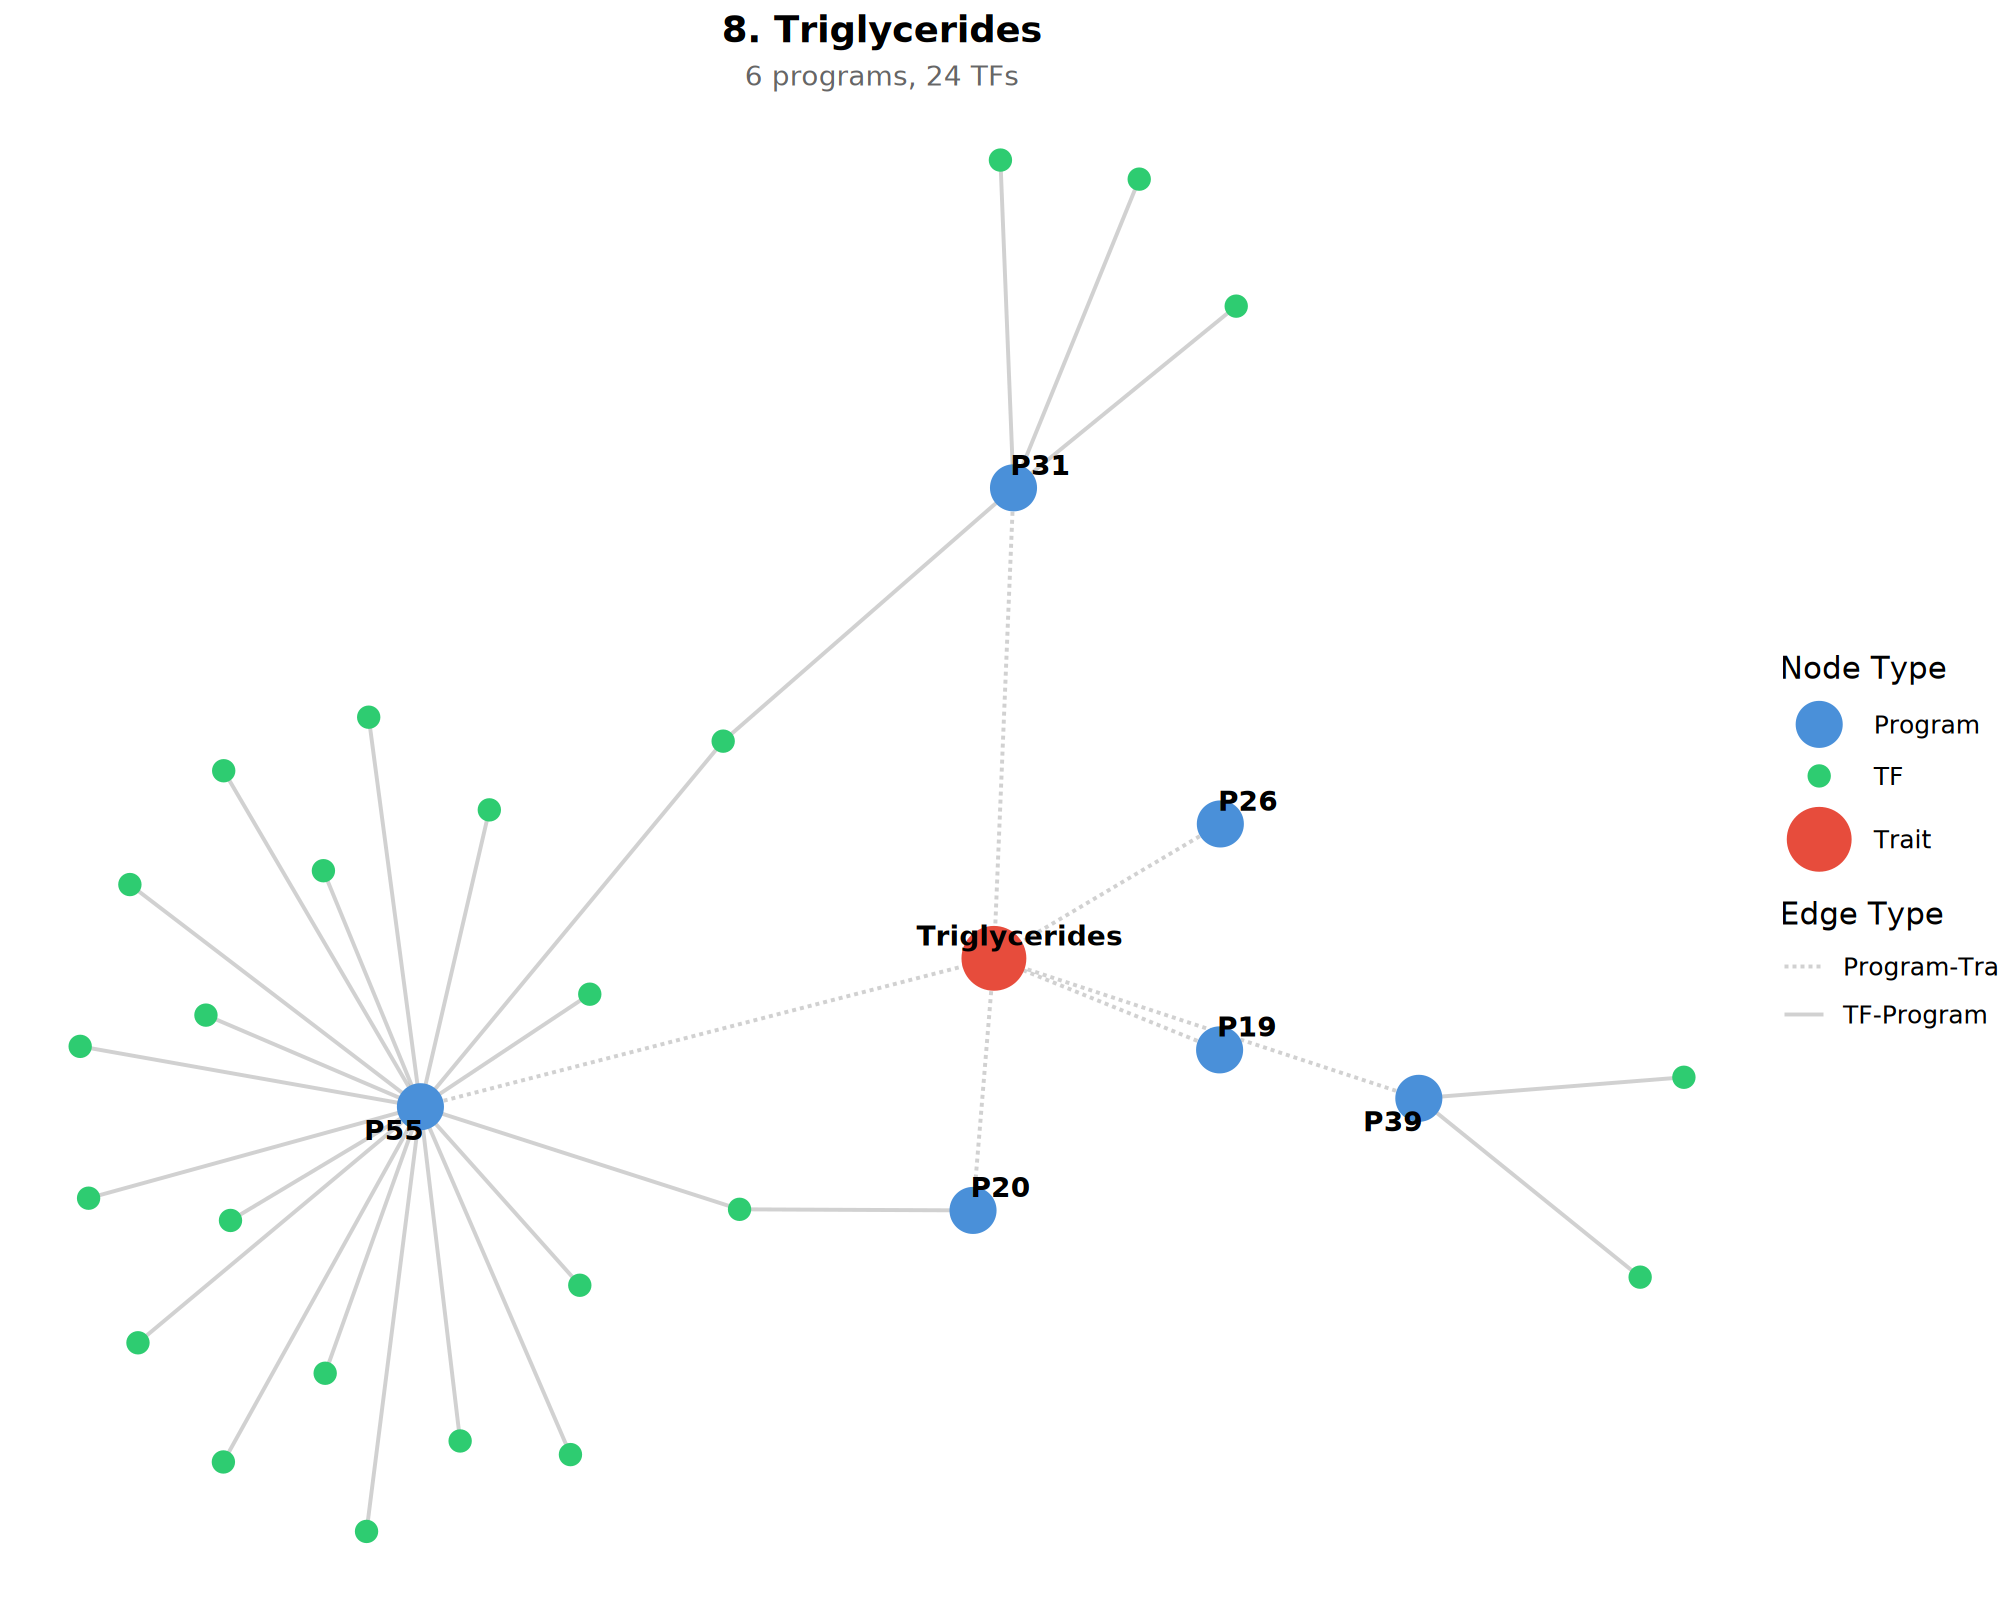

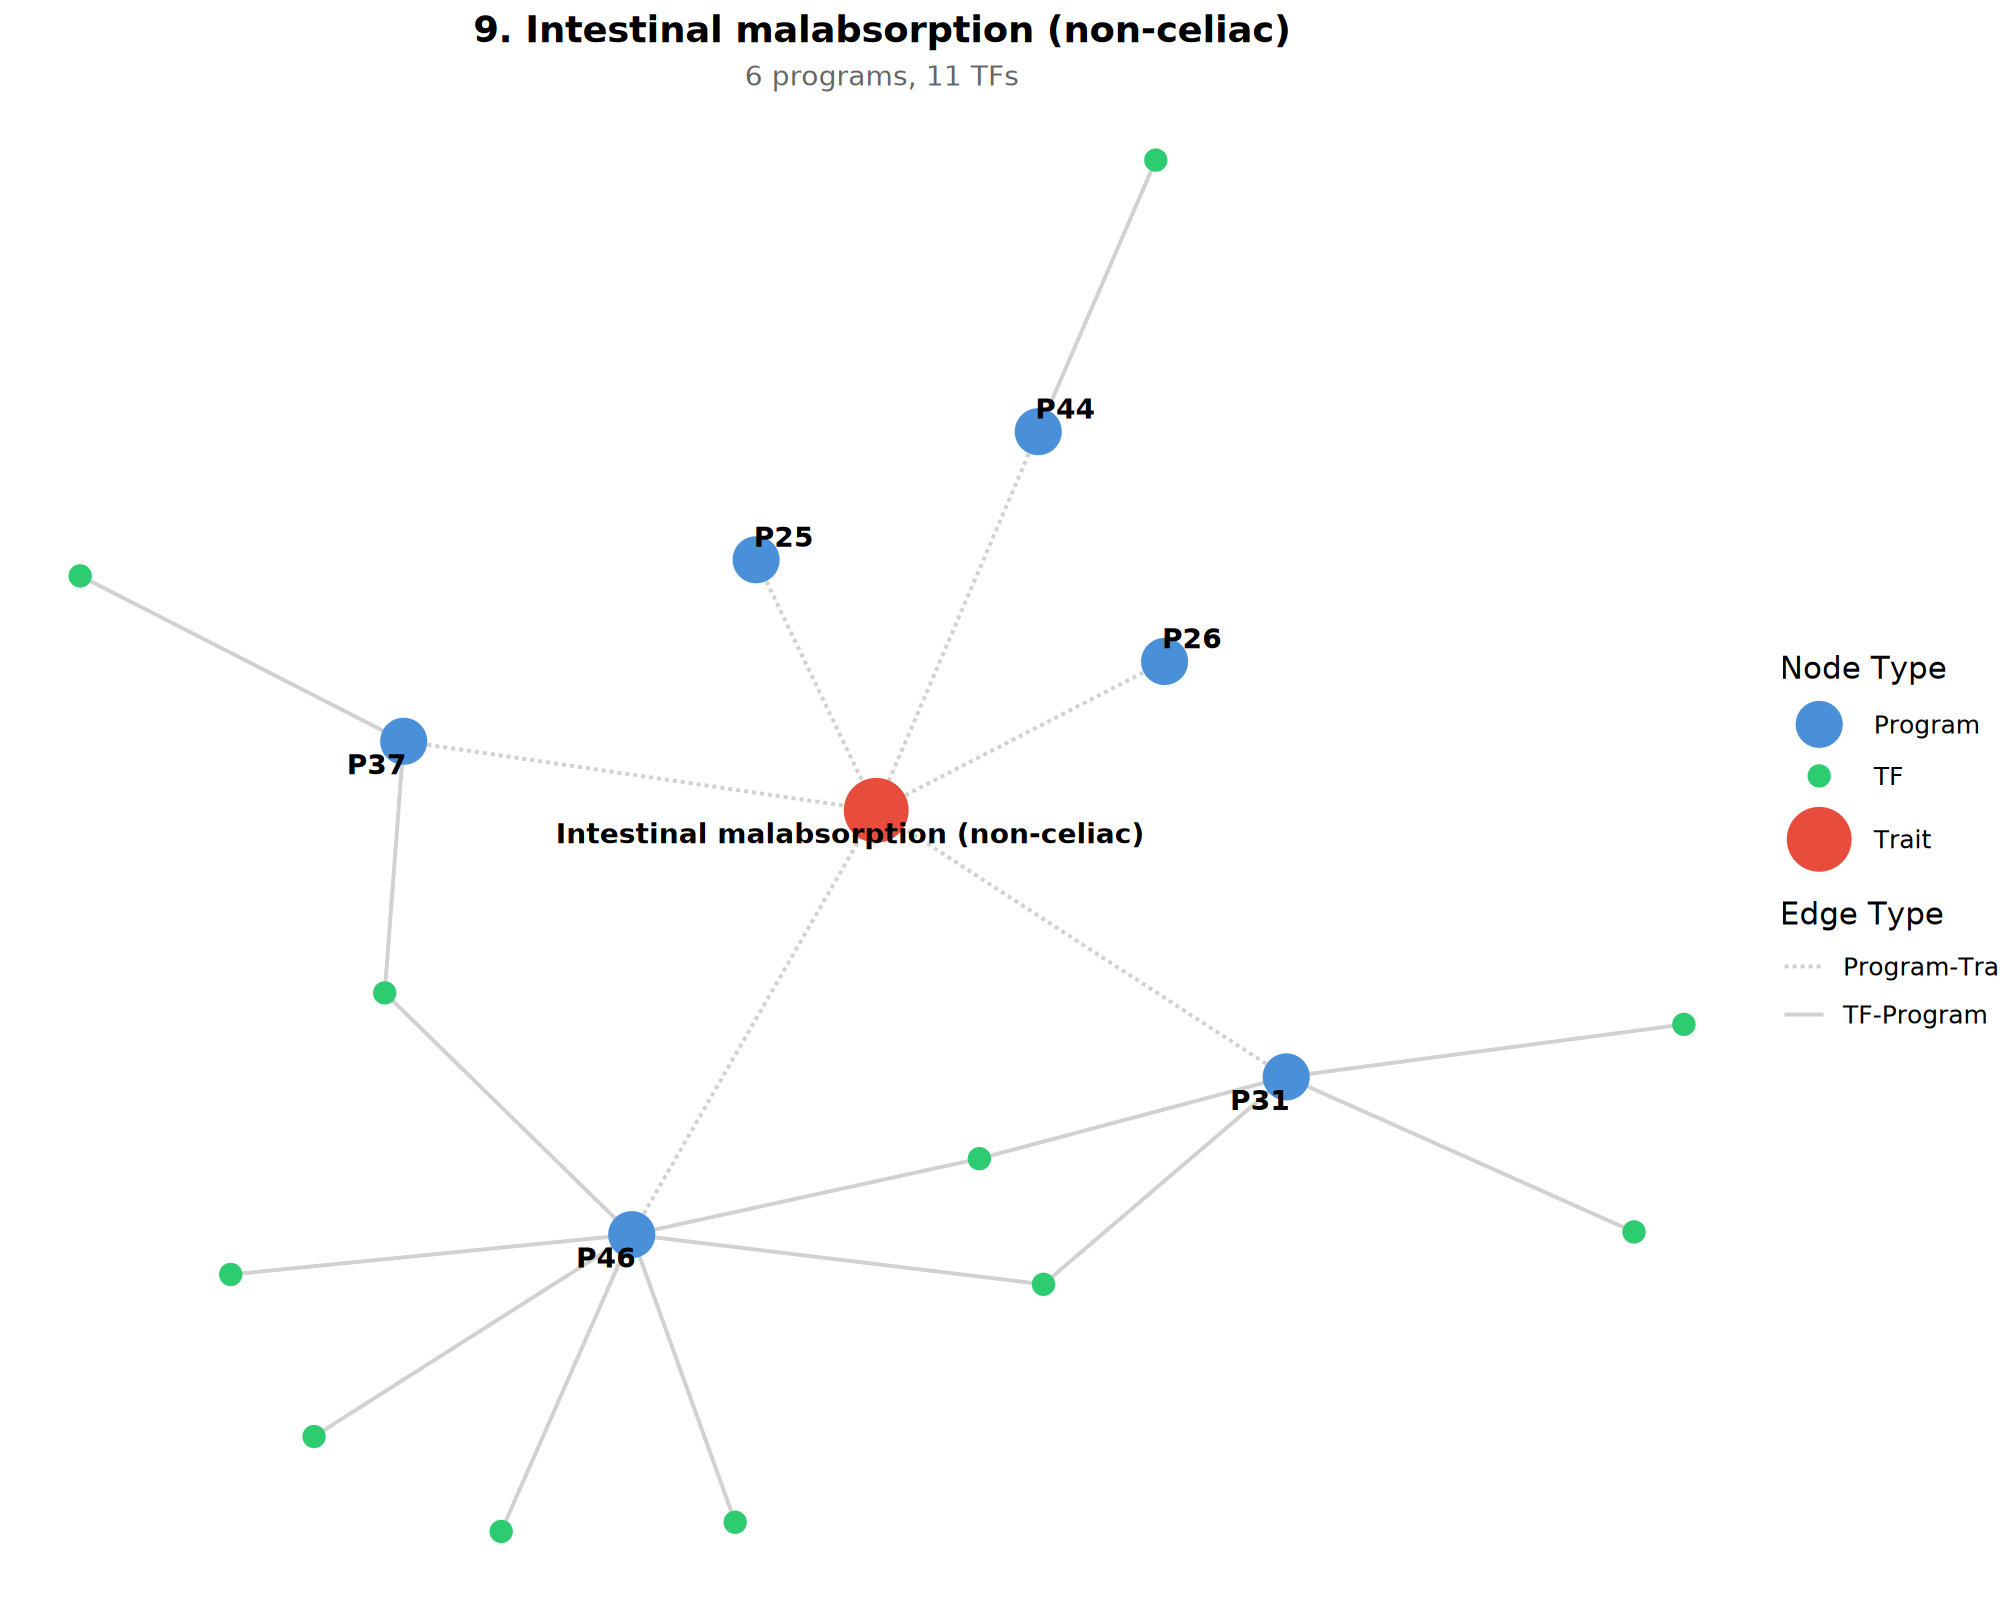

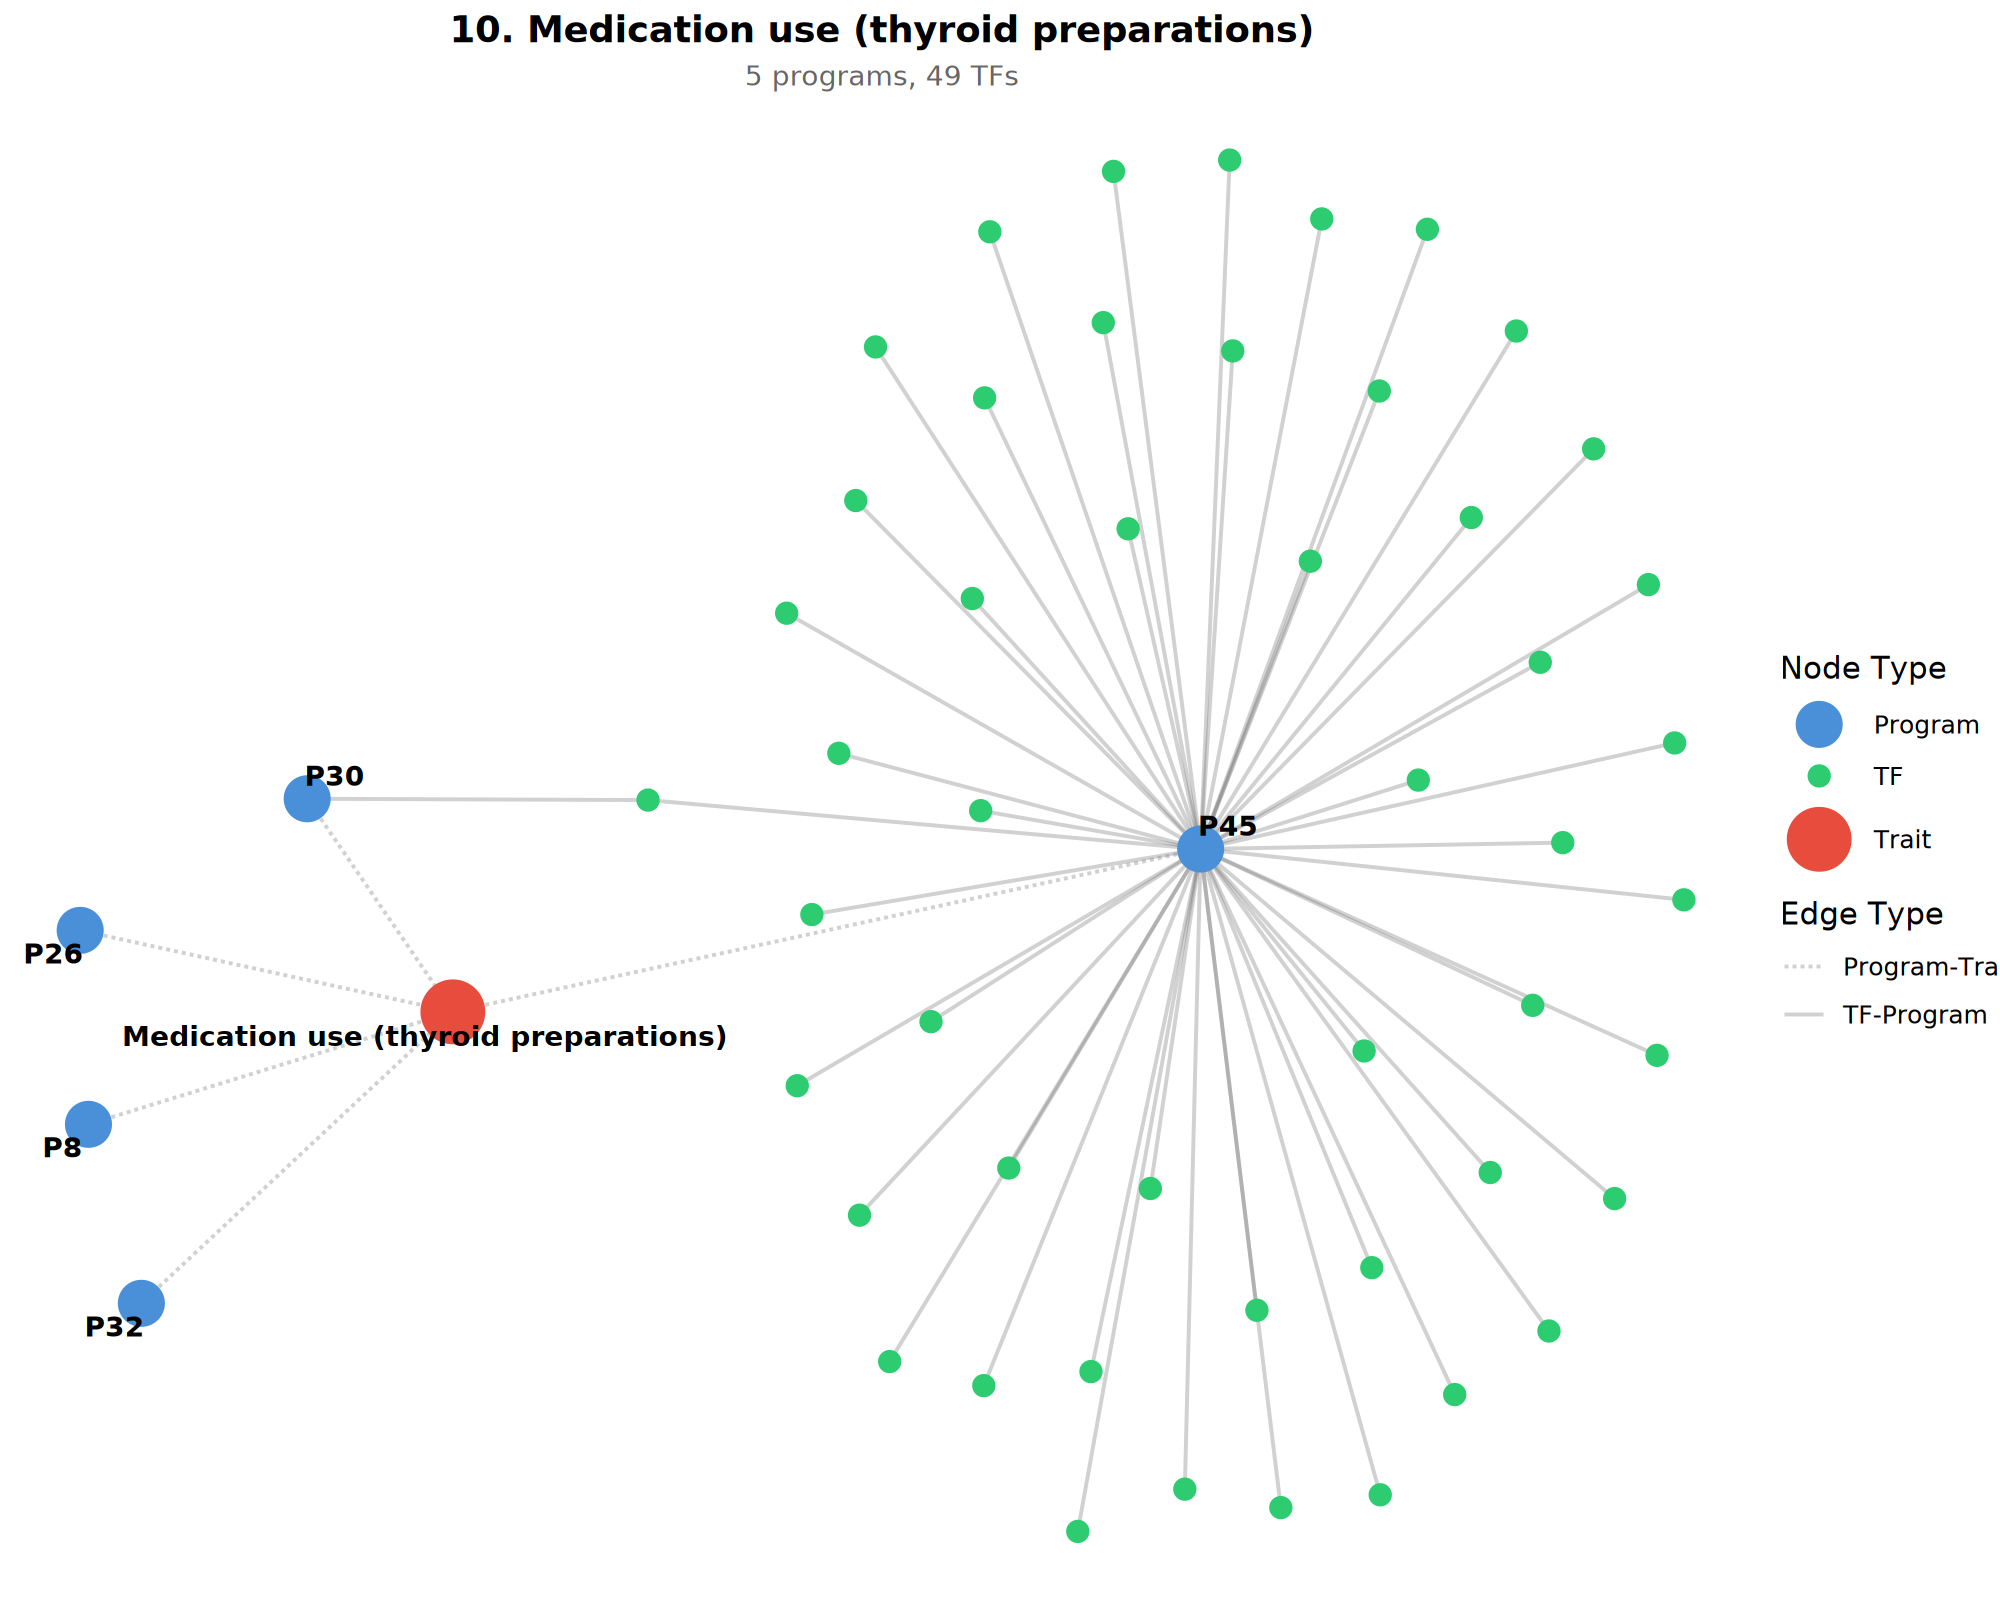

In [7]:
options(repr.plot.width = 13, repr.plot.height = 8, repr.plot.res = 200)
# Top 10 endoderm traits - individual network plots
top10_endo <- endoderm_ranked %>% head(10)

options(repr.plot.width = 10, repr.plot.height = 8)

for (i in seq_len(nrow(top10_endo))) {
    this_term <- top10_endo$Term[i]
    this_label <- top10_endo$trait_label[i]

    # Program-Trait edges for this trait
    t_edges <- trait_dataframe %>%
        filter(Term == this_term, P.value < 0.05) %>%
        left_join(term_label_df, by = "Term") %>%
        mutate(from = paste0("P", program_name), to = trait_label,
               edge_type = "Program-Trait") %>%
        select(from, to, edge_type)

    progs <- unique(t_edges$from)

    # TF-Program edges
    tf_e <- sig_perturb %>%
        filter(program_label %in% progs) %>%
        mutate(from = target_name, to = program_label,
               edge_type = "TF-Program") %>%
        select(from, to, edge_type)

    all_e <- bind_rows(t_edges, tf_e)
    if (nrow(all_e) == 0) next

    g <- graph_from_data_frame(all_e, directed = FALSE)
    trait_names <- unique(t_edges$to)
    V(g)$type <- case_when(
        V(g)$name %in% trait_names ~ "Trait",
        grepl("^P\\d+$", V(g)$name) ~ "Program",
        TRUE ~ "TF"
    )

    tg <- as_tbl_graph(g)

    p <- ggraph(tg, layout = "fr") +
        geom_edge_link(aes(linetype = edge_type), alpha = 0.3, color = "grey40") +
        scale_edge_linetype_manual(values = c("TF-Program" = "solid", "Program-Trait" = "dashed"),
                                    name = "Edge Type") +
        geom_node_point(aes(color = type, size = type)) +
        scale_color_manual(values = c("TF" = "#2ECC71", "Program" = "#4A90D9", "Trait" = "#E74C3C"),
                           name = "Node Type") +
        scale_size_manual(values = c("TF" = 3, "Program" = 7, "Trait" = 10),
                          name = "Node Type") +
        geom_node_text(
            aes(label = ifelse(type != "TF", name, "")),
            repel = TRUE, size = 3.5, max.overlaps = 25, fontface = "bold"
        ) +
        theme_void() +
        labs(title = paste0(i, ". ", this_label),
             subtitle = paste0(length(progs), " programs, ", n_distinct(tf_e$from), " TFs")) +
        theme(plot.title = element_text(hjust = 0.5, size = 13, face = "bold"),
              plot.subtitle = element_text(hjust = 0.5, size = 10, color = "grey40"),
              legend.position = "right")

    print(p)
}

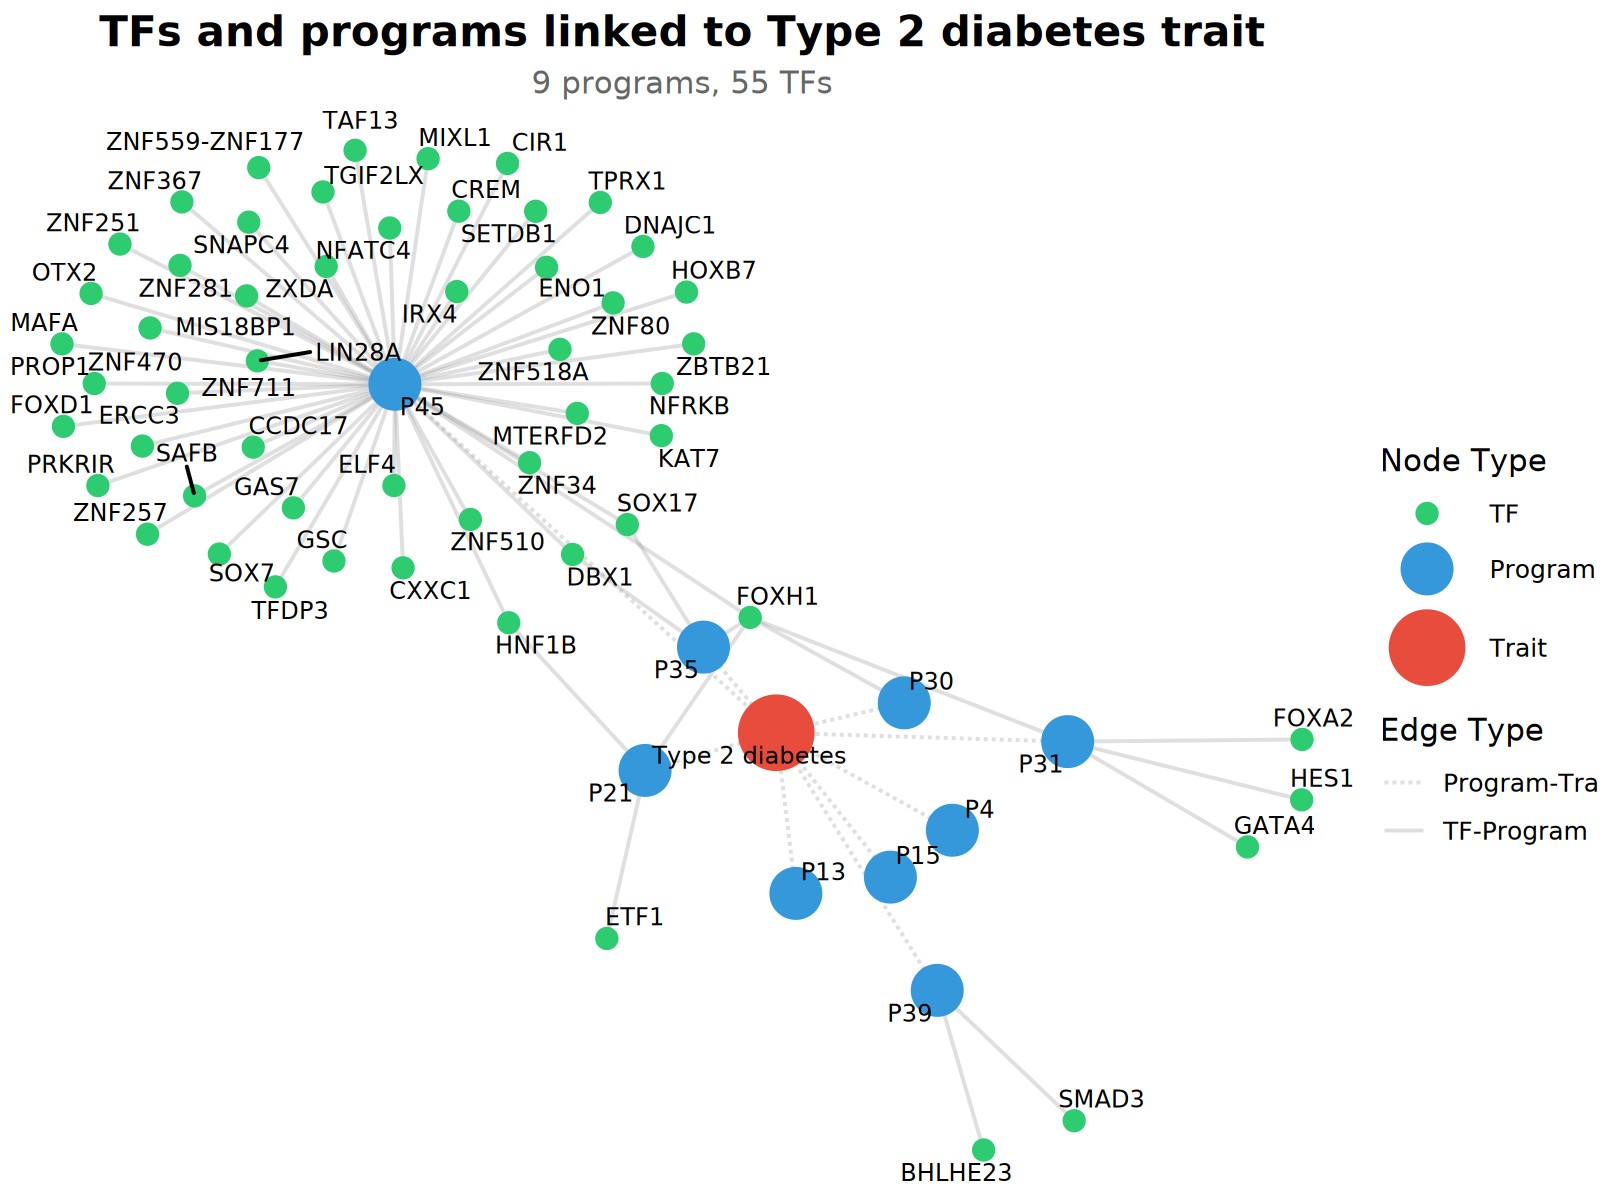

In [9]:
# T2D network with all nodes labeled
t2d_row <- endoderm_ranked %>% filter(grepl("[Dd]iabet|T2D", trait_label))
t2d_term <- t2d_row$Term[1]
t2d_label <- t2d_row$trait_label[1]

t_edges <- trait_dataframe %>%
    filter(Term == t2d_term, P.value < 0.05) %>%
    left_join(term_label_df, by = "Term") %>%
    mutate(from = paste0("P", program_name), to = trait_label,
           edge_type = "Program-Trait") %>%
    select(from, to, edge_type)

progs <- unique(t_edges$from)

tf_e <- sig_perturb %>%
    filter(program_label %in% progs) %>%
    mutate(from = target_name, to = program_label,
           edge_type = "TF-Program") %>%
    select(from, to, edge_type)

all_e <- bind_rows(t_edges, tf_e)

g <- graph_from_data_frame(all_e, directed = FALSE)
trait_names <- unique(t_edges$to)
V(g)$type <- case_when(
    V(g)$name %in% trait_names ~ "Trait",
    grepl("^P\\d+$", V(g)$name) ~ "Program",
    TRUE ~ "TF"
)
V(g)$type <- factor(V(g)$type, levels = c("TF", "Program", "Trait"))

tg <- as_tbl_graph(g)

options(repr.plot.width = 8, repr.plot.height = 6)

ggraph(tg, layout = "fr") +
    geom_edge_link(aes(linetype = edge_type), alpha = 0.25, color = "grey50") +
    scale_edge_linetype_manual(values = c("TF-Program" = "solid", "Program-Trait" = "dashed"),
                                name = "Edge Type") +
    geom_node_point(aes(color = type, size = type)) +
    scale_color_manual(
        values = c("TF" = "#2ECC71", "Program" = "#3498DB", "Trait" = "#E74C3C"),
        breaks = c("TF", "Program", "Trait"),
        name = "Node Type"
    ) +
    scale_size_manual(
        values = c("TF" = 3, "Program" = 8, "Trait" = 12),
        breaks = c("TF", "Program", "Trait"),
        name = "Node Type"
    ) +
    geom_node_text(aes(label = name), repel = TRUE, size = 3, max.overlaps = 50) +
    theme_void() +
    labs(title = glue::glue('TFs and programs linked to {t2d_label} trait'),
         subtitle = paste0(length(progs), " programs, ", n_distinct(tf_e$from), " TFs")) +
    theme(plot.title = element_text(hjust = 0.5, size = 15, face = "bold"),
          plot.subtitle = element_text(hjust = 0.5, size = 11, color = "grey40"),
          legend.position = "right")